In [1]:
#ENV: HI
# Import data processing modules
import pandas as pd # used throughout the code
import numpy as np # used throughout the code

# Import visualization modules
import matplotlib.pyplot as plt # used for simple bar charts and as basis for plotly and seaborn library
from textwrap import fill # used for scatterplot in data analysis section after disaggregation

# Display options
pd.options.display.float_format = '{:,.2f}'.format #limits printed decimal points to two


geo = False

if geo == True: #ENV: geo_env
    import geopandas as gpd
    
    import matplotlib.colors as colors
    from matplotlib import colormaps
    from matplotlib.gridspec import GridSpec
    from matplotlib import rcParams

    #%% Global plotting settings
    #rcParams['font.family'] = 'Bitstream Vera Sans'
    rcParams['font.size'] = 10

    #shapefiles
    nuts = gpd.read_file('data/input_detailing_NUTS/NUTS_RG_20M_2024_3035.gpkg') #need to match the coordinate systems between gdf and nuts
    bld = nuts.loc[nuts['NUTS_ID'].str.len() == 2]
    bld = bld[['NUTS_ID', 'geometry']]
    nuts = nuts.loc[nuts['NUTS_ID'].str.len() == 5] #only NUTS3 level
    nuts = nuts[['NUTS_ID', 'geometry']]
else:
    import seaborn as sns
    import plotly.express as px # used for all stacked bar charts
    import plotly.graph_objects as go # used for marimekko plot and for annotating stacked bar charts

## Sanity check: all regions consistent?
- household size
- floor area per capita
- population size
- population growth

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_21358/1406198201.py:13: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  df = df.groupby(by=['region_nuts', 'year'], axis=0).mean(numeric_only=True).reset_index()


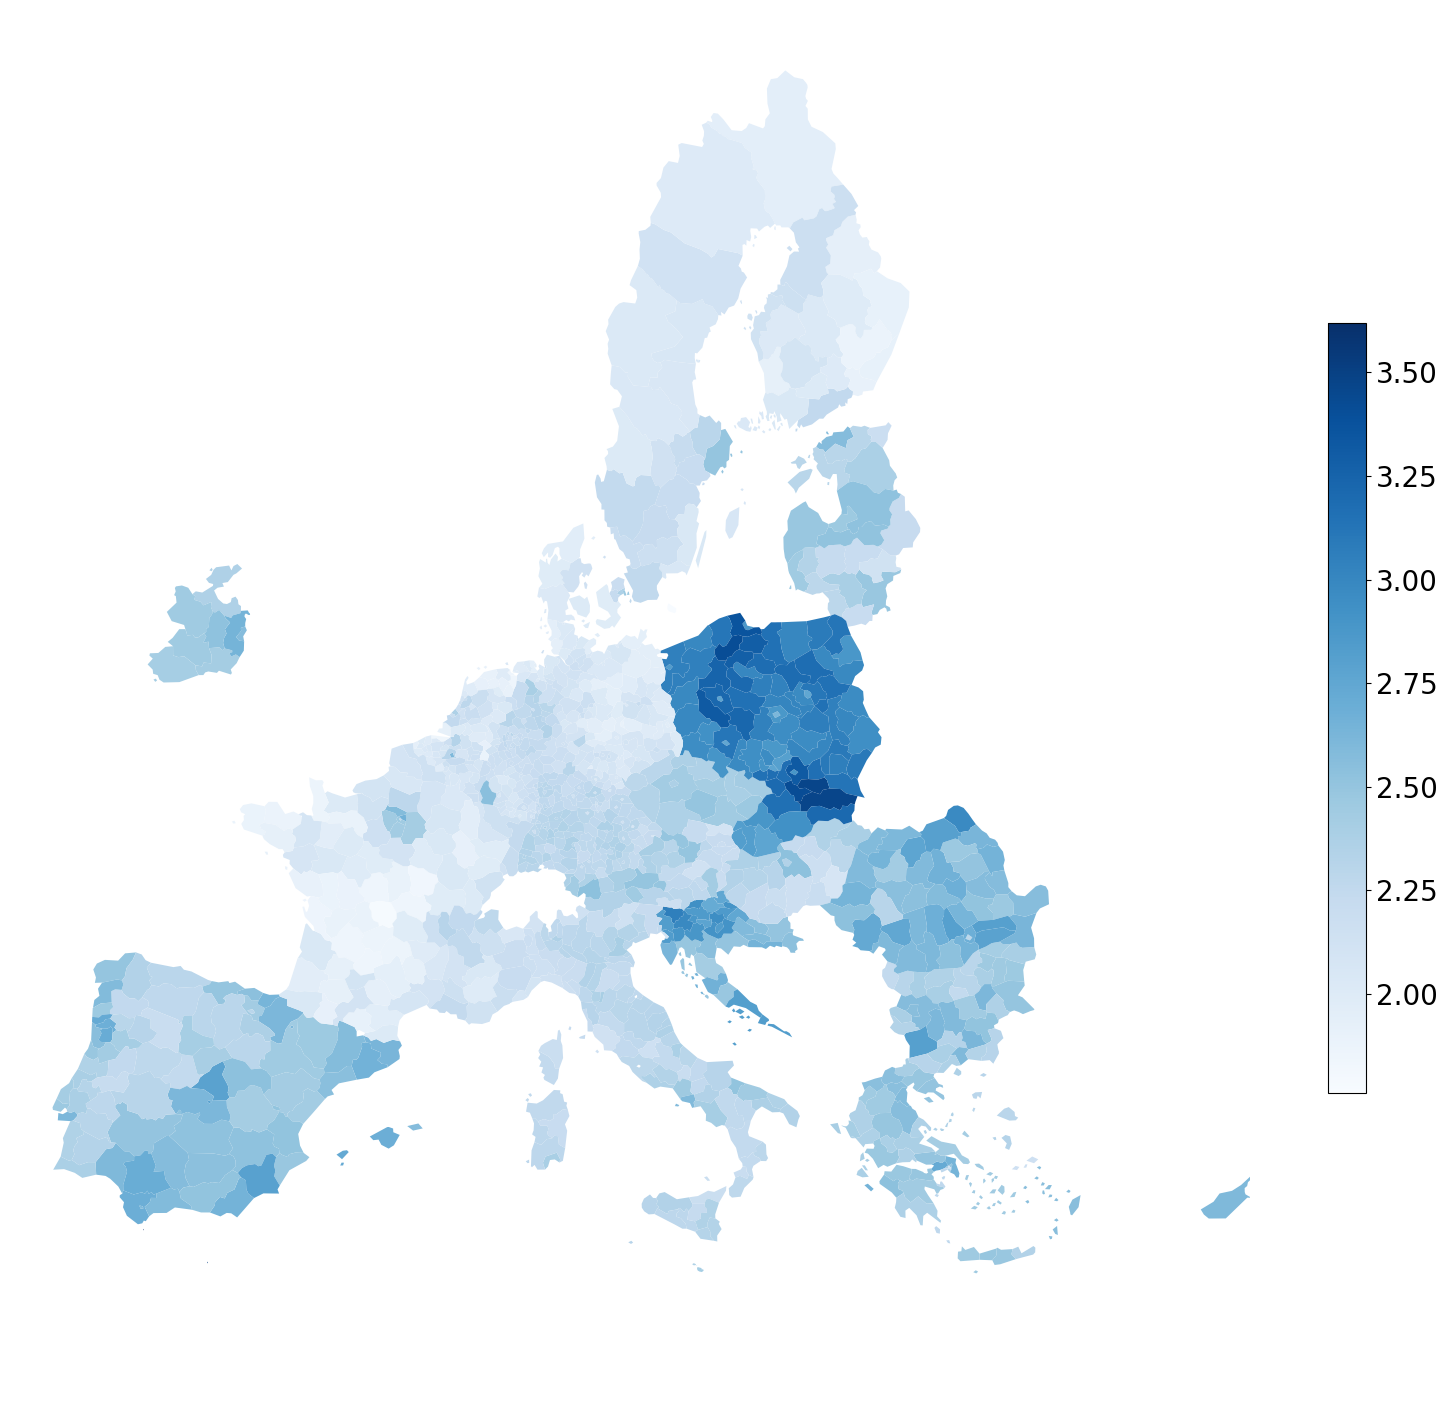

In [2]:
#data import
file = 'hh_size_rev_nuts.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)

if geo==False:
    for i in df.columns.drop(['region_nuts', 'value']):
        hue=i
        sns.histplot(data=df, x='value', hue=hue)
        plt.savefig('plots/'+file[0:8]+hue+'.png')
        plt.show()
        plt.close()
else:
    df = df.groupby(by=['region_nuts', 'year'], axis=0).mean(numeric_only=True).reset_index()

    #merging shape with data
    df['NUTS_ID'] = df.region_nuts.str[10:]
    df_gdf = pd.merge(df, nuts, on='NUTS_ID')

    year = 2050
    gdf = gpd.GeoDataFrame(df_gdf[df_gdf['year']==year])
    col = 'value'
    ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
                #cmap='RdBu_r', 
                cmap='Blues', #inferno_r
                #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
                #norm=custom_norm, 
                edgecolor=None,
                missing_kwds={'color': 'lightgrey'},
                legend_kwds={"shrink":.5},)
    ax.figure.axes[1].tick_params(labelsize=20)
    ax.set_xlim(0.25e7, 0.65e7)
    ax.set_ylim(1e6, 5.5e6)
    ax.set_axis_off()
    plt.savefig('plots/map_'+file[0:8]+'_'+str(year)+'.png')
    plt.show()

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_21358/2520756445.py:12: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  df = df.groupby(by=['region_nuts', 'year'], axis=0).mean(numeric_only=True).reset_index()


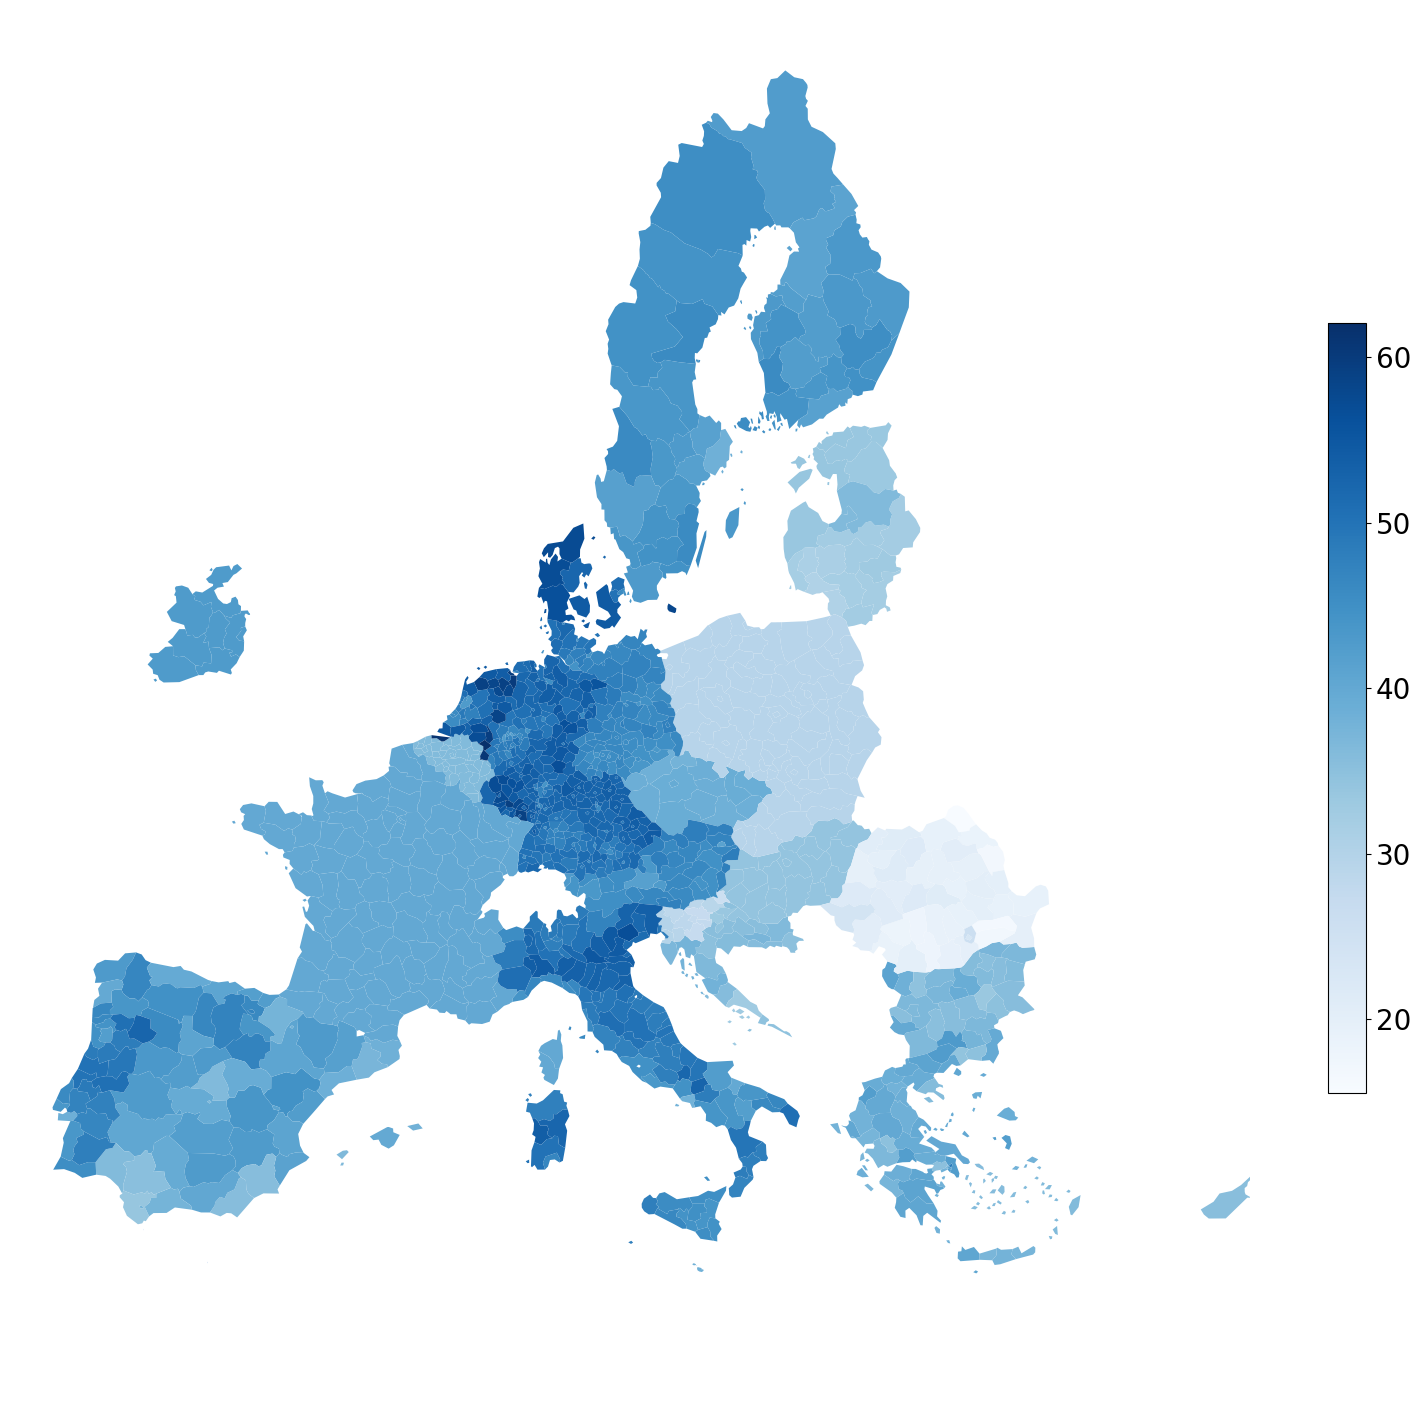

In [6]:
#data import
file = 'floor_resid_ssp2_rev_nuts.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
if geo==False:
    for i in df.columns.drop(['region_nuts', 'value']):
        hue=i
        sns.histplot(data=df, x='value', hue=hue)
        plt.savefig('plots/'+file[0:8]+hue+'.png')
        plt.show()
        plt.close()
else:
    df = df.groupby(by=['region_nuts', 'year'], axis=0).mean(numeric_only=True).reset_index()

    #merging shape with data
    df['NUTS_ID'] = df.region_nuts.str[10:]
    df_gdf = pd.merge(df, nuts, on='NUTS_ID')

    year = 2020
    gdf = gpd.GeoDataFrame(df_gdf[df_gdf['year']==year])
    col = 'value'
    ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
                #cmap='RdBu_r', 
                cmap='Blues', #inferno_r
                #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
                #norm=custom_norm, 
                edgecolor=None,
                missing_kwds={'color': 'lightgrey'},
                legend_kwds={"shrink":.5},)
    ax.figure.axes[1].tick_params(labelsize=20)
    ax.set_xlim(0.25e7, 0.65e7)
    ax.set_ylim(1e6, 5.5e6)
    ax.set_axis_off()
    plt.savefig('plots/map_'+file[0:8]+'_'+str(year)+'.png', bbox_inches='tight')
    plt.show()

#floor area per capita/dwelling data only available for some countries for EU, therefore countries like France show uniform floor area estimates

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_21358/1330431854.py:12: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  df = df.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).mul(1e6).reset_index()


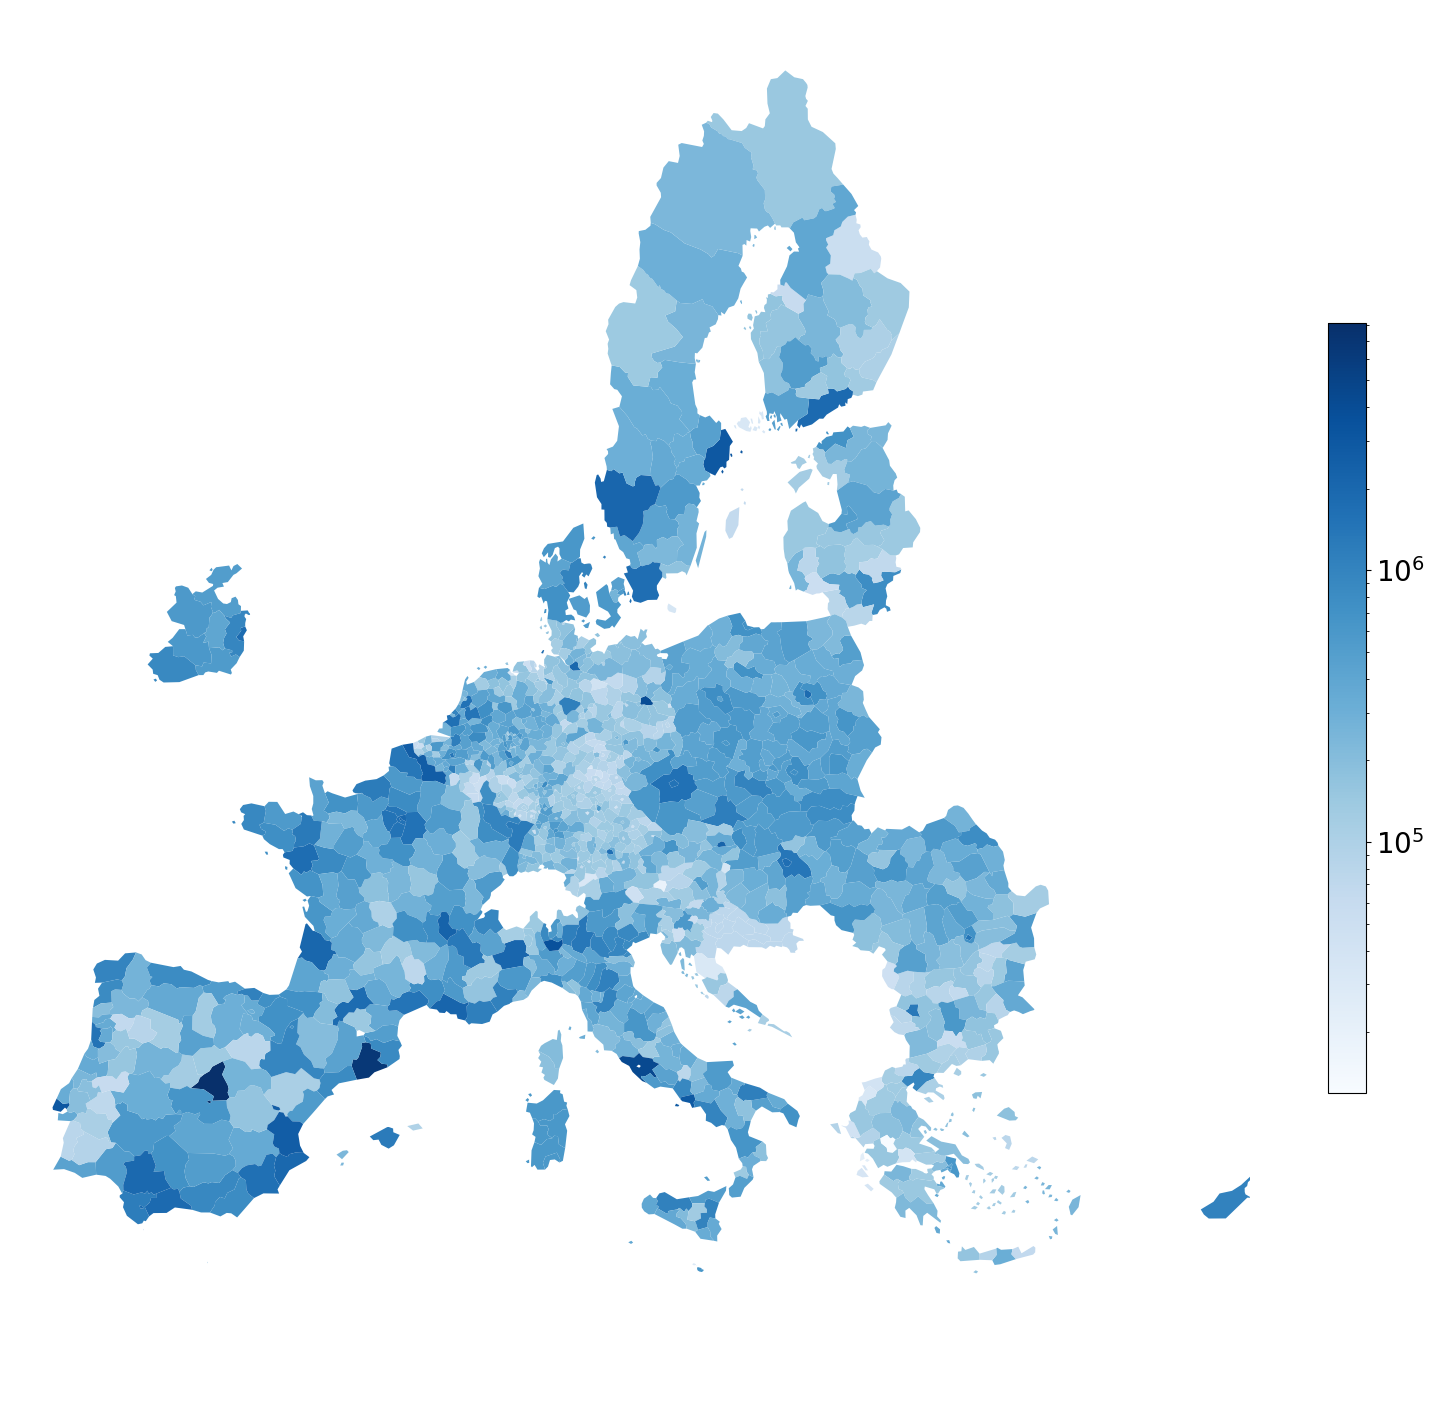

In [10]:
#data import
file = 'pop_clim_rev_SSP2_nuts.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
if geo==False:
    for i in df.columns.drop(['region_nuts', 'value']):
        hue=i
        sns.histplot(data=df, x='value', hue=hue)
        plt.savefig('plots/'+file[0:8]+hue+'.png')
        plt.show()
        plt.close()
else:
    df = df.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).mul(1e6).reset_index()

    #merging shape with data
    df['NUTS_ID'] = df.region_nuts.str[10:]
    df_gdf = pd.merge(df, nuts, on='NUTS_ID')

    year = 2050
    gdf = gpd.GeoDataFrame(df_gdf[df_gdf['year']==year])
    col = 'value'
    ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
                #cmap='RdBu_r', 
                cmap='Blues', #inferno_r
                norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
                #norm=custom_norm, 
                edgecolor=None,
                missing_kwds={'color': 'lightgrey'},
                legend_kwds={"shrink":.5},)
    ax.figure.axes[1].tick_params(labelsize=20)
    ax.set_xlim(0.25e7, 0.65e7)
    ax.set_ylim(1e6, 5.5e6)
    ax.set_axis_off()
    plt.savefig('plots/map_'+file[0:8]+'_'+str(year)+'.png', bbox_inches='tight')
    plt.show()

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_21358/1660134280.py:7: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  df = df.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).mul(1e6)


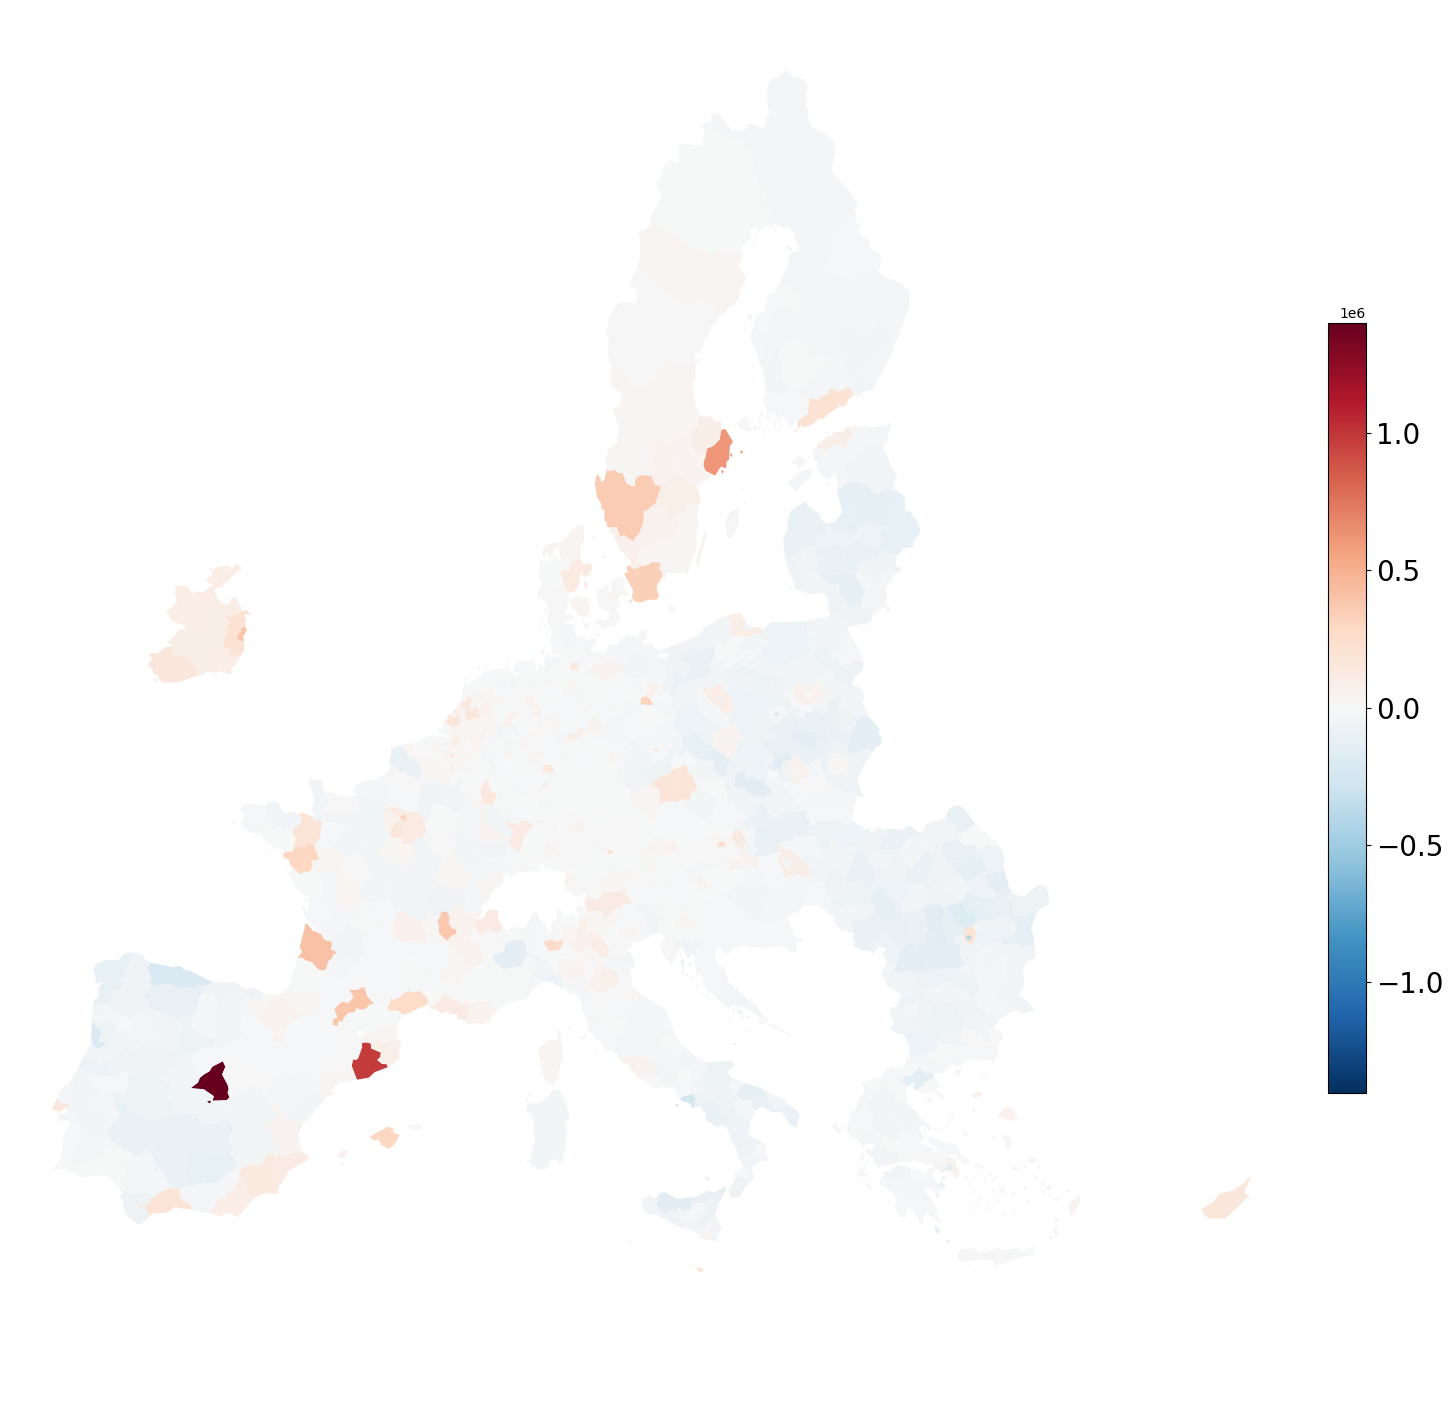

In [26]:
#data import
file = 'pop_clim_rev_SSP2_nuts.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
if geo==False:
    None
else:
    df = df.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).mul(1e6)
    df = df.unstack('year').droplevel(0, axis=1)
    df['pop_change'] = df[2050] - df[2020]
    df = df.loc[:,'pop_change'].reset_index()

    #merging shape with data
    df['NUTS_ID'] = df.region_nuts.str[10:]
    df_gdf = pd.merge(df, nuts, on='NUTS_ID')

    gdf = gpd.GeoDataFrame(df_gdf)
    col = 'pop_change'
    ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
                cmap='RdBu_r', 
                #cmap='Blues', #inferno_r
                #norm=colors.LogNorm(vmin=-1.5, vmax=1.5),
                norm=colors.CenteredNorm(), 
                edgecolor=None,
                missing_kwds={'color': 'lightgrey'},
                legend_kwds={"shrink":.5},)
    ax.figure.axes[1].tick_params(labelsize=20)
    ax.set_xlim(0.25e7, 0.65e7)
    ax.set_ylim(1e6, 5.5e6)
    ax.set_axis_off()
    plt.savefig('plots/map_'+file[0:8]+'_'+'change20202050'+'.png', bbox_inches='tight')
    plt.show()

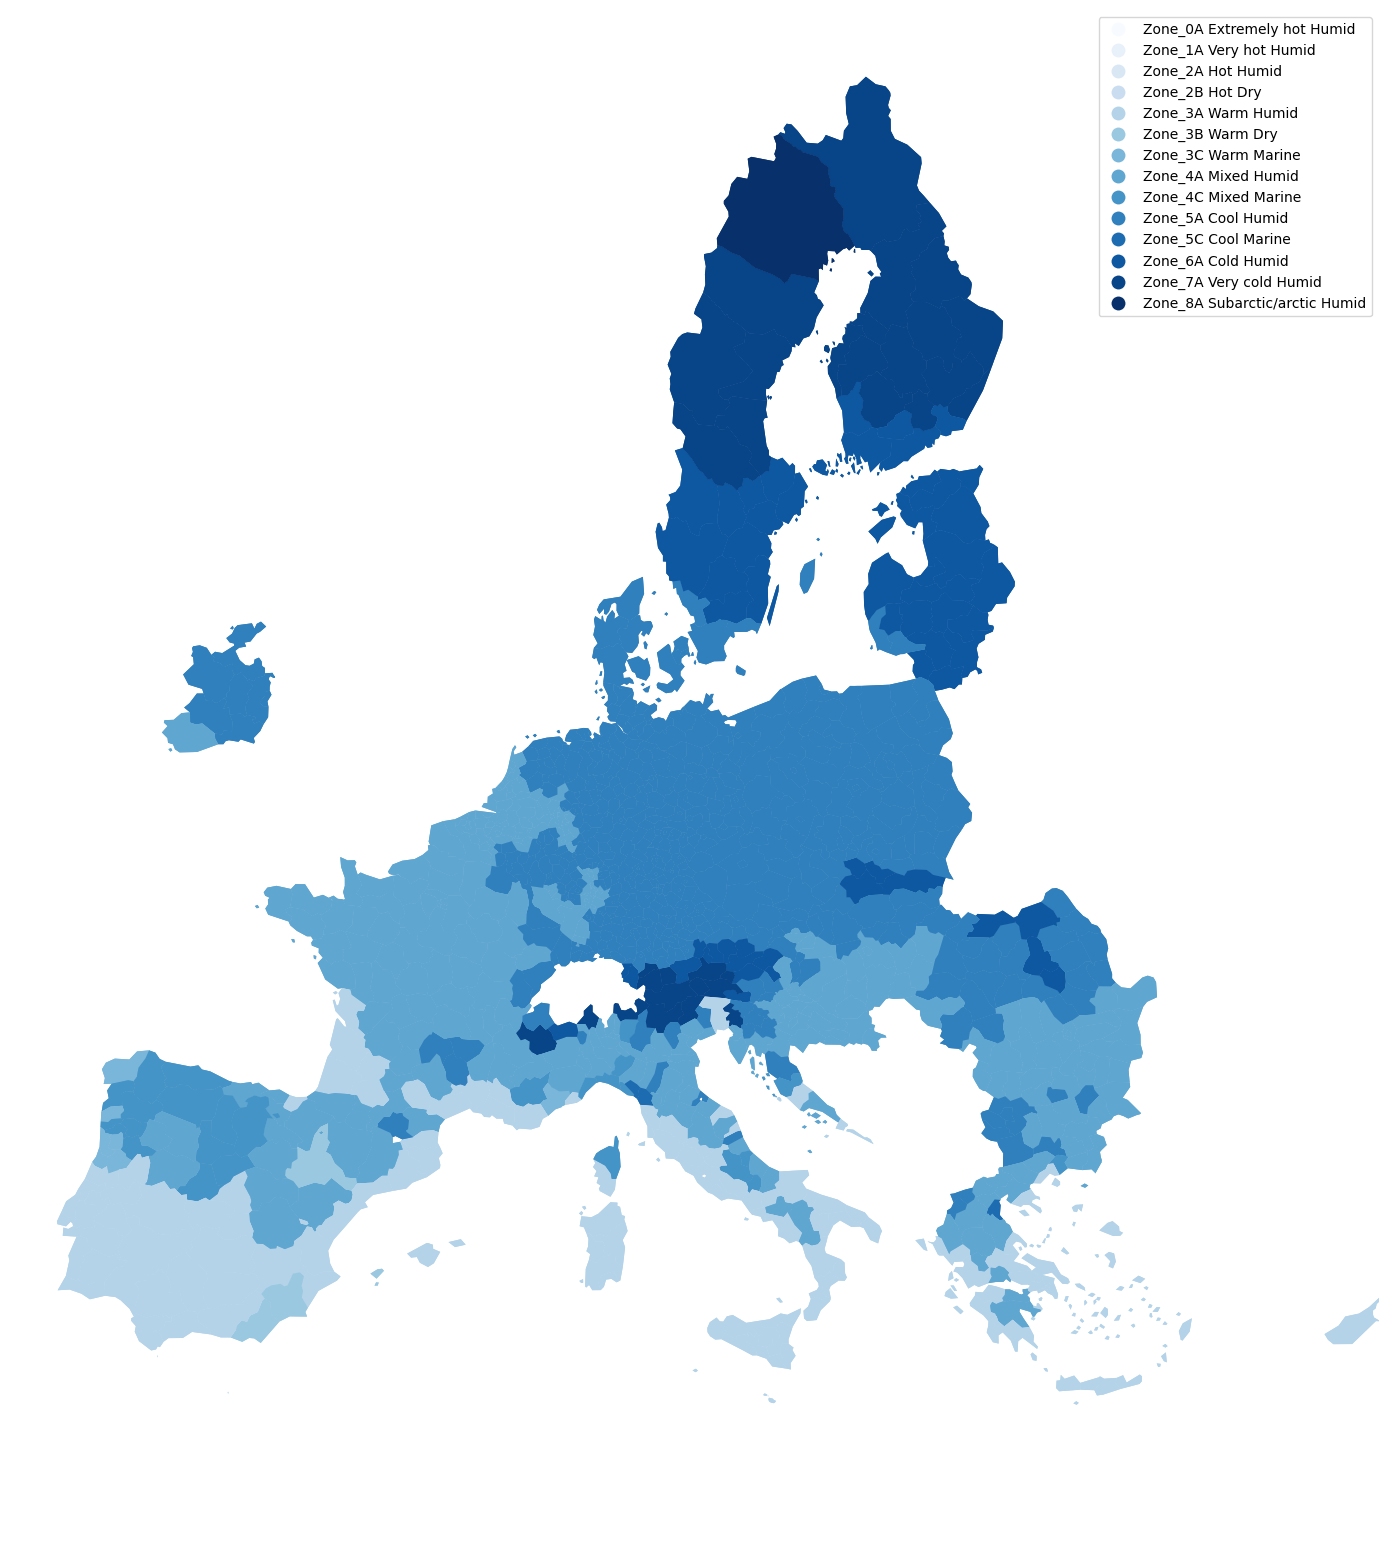

In [27]:
    file = 'climatic_zones_rev_nuts.csv'
    df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
    #merging shape with data
    df['NUTS_ID'] = df.region_nuts.str[10:]
    df_gdf = pd.merge(df, nuts, on='NUTS_ID')
    #year = 2050
    gdf = gpd.GeoDataFrame(df_gdf)
    col = 'clim'
    ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
                #cmap='RdBu_r', 
                cmap='Blues', #inferno_r
                #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
                #norm=custom_norm, 
                edgecolor=None,
                missing_kwds={'color': 'lightgrey'},
                #legend_kwds={"shrink":.5},
                )
    #ax.figure.axes[1].tick_params(labelsize=20)
    ax.set_xlim(0.25e7, 0.65e7)
    ax.set_ylim(1e6, 5.5e6)
    ax.set_axis_off()
    plt.savefig('plots/map_'+file[0:8]+'_'+str(year)+'.png')
    plt.show()

In [28]:
    #calculating dwelling weights of dwellings in NUTS per country
    pop = pd.read_csv('data/input_csv_NUTS_2025_resid/pop_clim_rev_SSP2_nuts.csv')
    pop['mat'] = 'perm'
    hhsize = pd.read_csv('data/input_csv_NUTS_2025_resid/hh_size_rev_nuts.csv')
    hhsize['mat'] = 'perm'
    hhsize = hhsize.set_index(keys=hhsize.columns.drop('value').to_list())
    arch_shr = pd.read_csv('data/input_csv_NUTS_2025_resid/bld_shr_arch_resid_nuts.csv')
    arch_shr = arch_shr.set_index(keys=arch_shr.columns.drop('value').to_list())

    dwellings = pop.groupby(by=pop.columns.drop(['clim','value']).to_list()).sum(numeric_only=True).mul(1e6).div(hhsize).fillna(method='bfill') #.div((hhsize*arch_shr).groupby(level=[0,1,2,4,5]).sum()).fillna(method='bfill')

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_51788/335572265.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dwellings = pop.groupby(by=pop.columns.drop(['clim','value']).to_list()).sum(numeric_only=True).mul(1e6).div(hhsize).fillna(method='bfill') #.div((hhsize*arch_shr).groupby(level=[0,1,2,4,5]).sum()).fillna(method='bfill')


In [27]:
    #calculating dwelling weights of dwellings in NUTS per country
    pop_ = pd.read_csv('data/input_csv_NUTS_2025_resid/pop_clim_rev_SSP2_nuts_bld.csv')
    pop_['mat'] = 'perm'
    hhsize_ = pd.read_csv('data/input_csv_NUTS_2025_resid/hh_size_rev_nuts_bld.csv')
    hhsize_['mat'] = 'perm'
    hhsize_ = hhsize_.set_index(keys=hhsize_.columns.drop('value').to_list())
    arch_shr_ = pd.read_csv('data/input_csv_NUTS_2025_resid/bld_shr_arch_resid_nuts_bld.csv')
    arch_shr_ = arch_shr_.set_index(keys=arch_shr_.columns.drop('value').to_list())

    dwellings_ = pop_.groupby(by=pop_.columns.drop(['clim','value']).to_list()).sum(numeric_only=True).mul(1e6).div(hhsize_).fillna(method='bfill')

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_51788/3491701205.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dwellings_ = pop_.groupby(by=pop_.columns.drop(['clim','value']).to_list()).sum(numeric_only=True).mul(1e6).div(hhsize_).fillna(method='bfill')


In [29]:
dwellings_.xs(2020, level='year').groupby('region_bld').sum() / dwellings.xs(2020, level='year').groupby('region_bld').sum()

,value
region_bld,
C-EEU-BGR,1.00
C-EEU-CZE,1.00
C-EEU-EST,1.00
C-EEU-HRV,1.00
C-EEU-HUN,1.00
C-EEU-LTU,1.00
C-EEU-LVA,1.00
C-EEU-POL,1.00
C-EEU-ROU,1.00


In [34]:
file = 'stock_baseyear_resid_rev_share_nuts_bld.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
df.groupby(by=df.columns.drop(['value', 'yr_con', 'bld_age']).to_list()).sum()

yr_con  \
region_bld region_gea urt clim                           mat  arch           
C-EEU-BGR  EEU        rur Zone_4A Mixed Humid            perm mfh    27815   
                                                              sfh    27815   
                          Zone_5A Cool Humid             perm mfh    27815   
                                                              sfh    27815   
                      urb Zone_4A Mixed Humid            perm mfh    27815   
...                                                                    ...   
C-WEU-SWE  WEU        urb Zone_6A Cold Humid             perm sfh    27815   
                          Zone_7A Very cold Humid        perm mfh    27815   
                                                              sfh    27815   
                          Zone_8A Subarctic/arctic Humid perm mfh    27815   
                                                              sfh    27815   

                                                                                         bld_age  \
region_bld region_gea urt clim                           mat  arch                                 
C-EEU-BGR  EEU        rur Zone_4A Mixed Humid            perm mfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
                                                              sfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
                          Zone_5A Cool Humid             perm mfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
                                                              sfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
                      urb Zone_4A Mixed Humid            perm mfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
...                                                                                          ...   
C-WEU-SWE  WEU        urb Zone_6A Cold Humid             perm sfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
                          Zone_7A Very cold Humid        perm mfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
                                                              sfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
                          Zone_8A Subarctic/arctic Humid perm mfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
                                                              sfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   

                                                                    value  
region_bld region_gea urt clim                           mat  arch         
C-EEU-BGR  EEU        rur Zone_4A Mixed Humid            perm mfh    0.60  
                                                              sfh    0.60  
                          Zone_5A Cool Humid             perm mfh    0.40  
                                                              sfh    0.40  
                      urb Zone_4A Mixed Humid            perm mfh    0.65  
...                                                                   ...  
C-WEU-SWE  WEU        urb Zone_6A Cold Humid             perm sfh    0.64  
                          Zone_7A Very cold Humid        perm mfh    0.12  
                                                              sfh    0.12  
                          Zone_8A Subarctic/arctic Humid perm mfh    0.03  
                                                              sfh    0.03  

[308 rows x 3 columns]

In [26]:
file = 'bld_shr_arch_resid_nuts.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
df.groupby(by=df.columns.drop(['value', 'arch']).to_list()).sum()

arch  value
region_bld region_nuts     urt mat  year               
C-EEU-BGR  C-EEU-BGR-BG311 rur perm 2015  mfhsfh   1.00
                                    2020  mfhsfh   1.00
                                    2025  mfhsfh   1.00
                                    2030  mfhsfh   1.00
                                    2035  mfhsfh   1.00
...                                          ...    ...
C-WEU-SWE  C-WEU-SWE-SE332 urb perm 2080  mfhsfh   1.00
                                    2085  mfhsfh   1.00
                                    2090  mfhsfh   1.00
                                    2095  mfhsfh   1.00
                                    2100  mfhsfh   1.00

[41940 rows x 2 columns]

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_14026/2933684970.py:11: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  df = df.groupby(by=['region_nuts', 'year', 'arch'], axis=0).mean(numeric_only=True).reset_index()


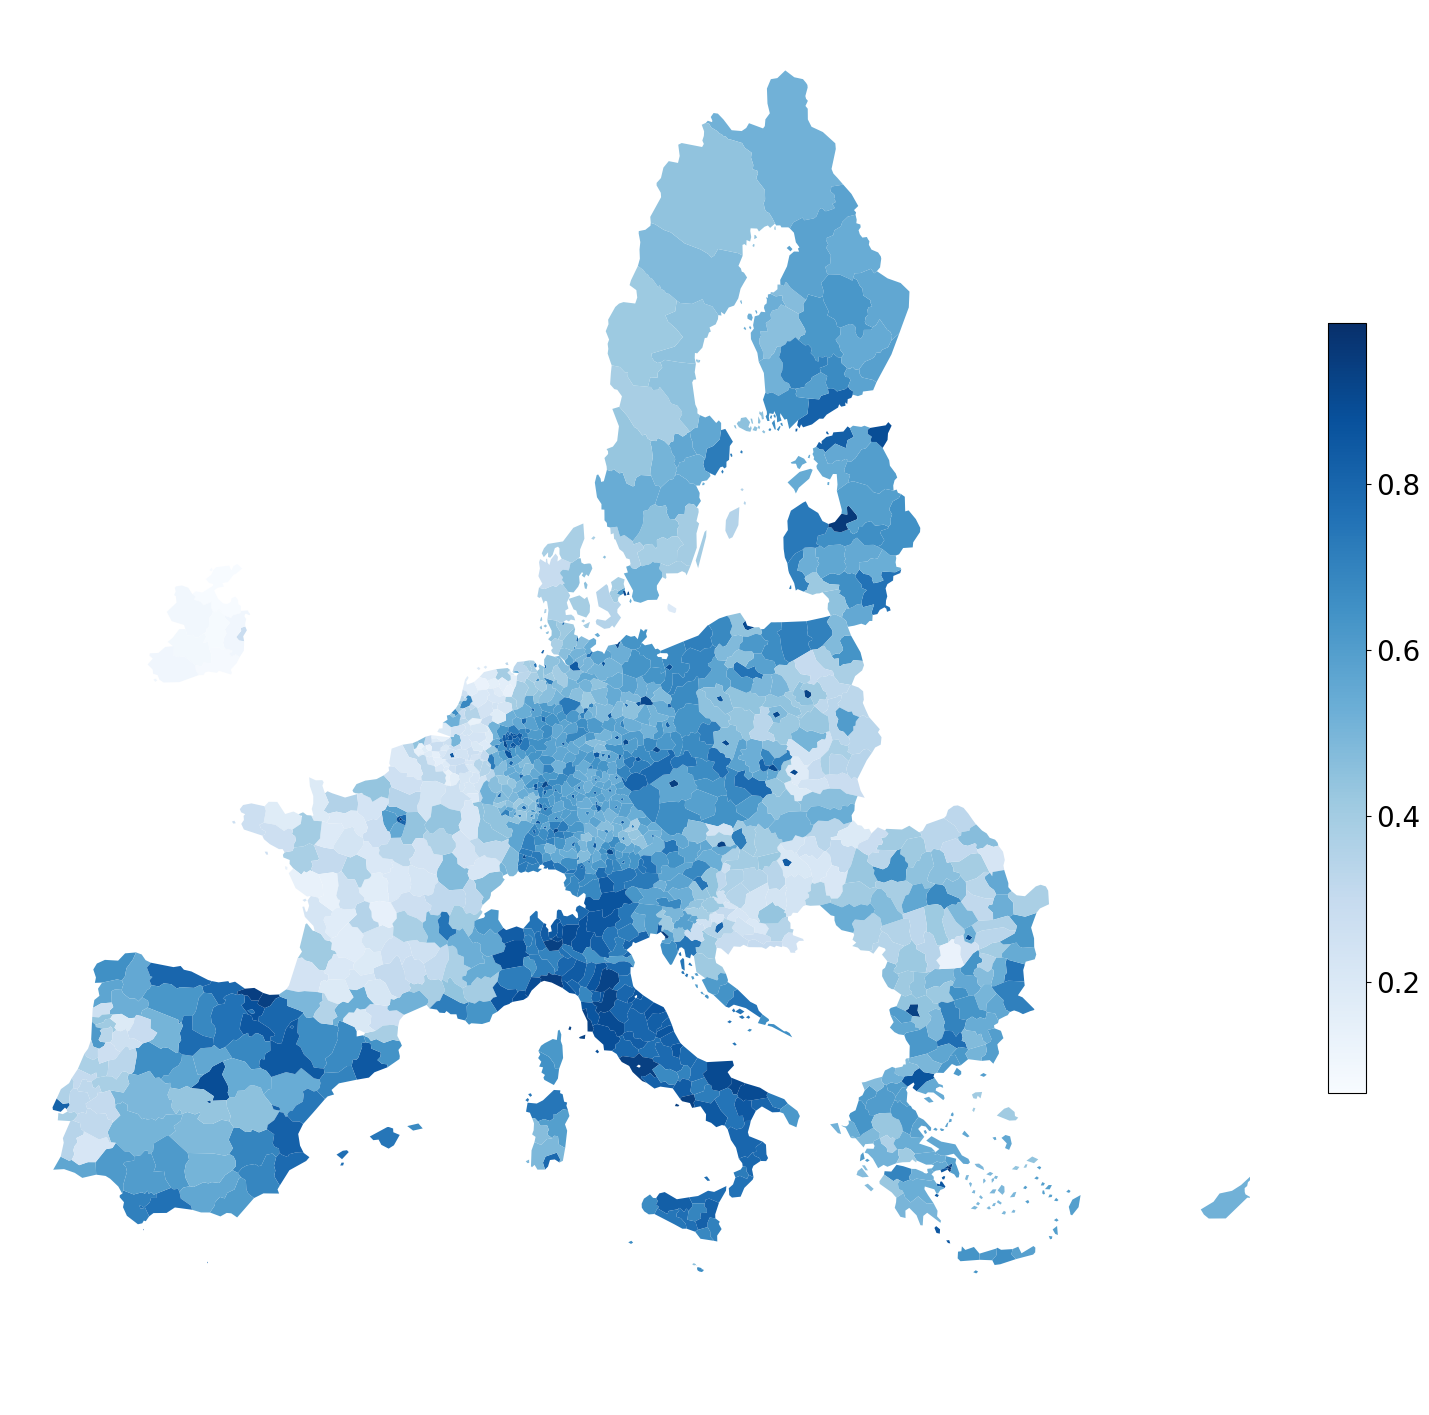

In [9]:
file = 'bld_shr_arch_resid_nuts.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
if geo==False:
    for i in df.columns.drop(['region_nuts', 'value']):
        hue=i
        sns.histplot(data=df, x='value', hue=hue)
        plt.savefig('plots/'+file[0:8]+hue+'.png')
        plt.show()
        plt.close()
else:
    df = df.groupby(by=['region_nuts', 'year', 'arch'], axis=0).mean(numeric_only=True).reset_index()

    #merging shape with data
    df['NUTS_ID'] = df.region_nuts.str[10:]
    df_gdf = pd.merge(df, nuts, on='NUTS_ID')

    year = 2050
    gdf = gpd.GeoDataFrame(df_gdf[(df_gdf['year']==year) & (df_gdf['arch']=='mfh')])
    col = 'value'
    ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
                #cmap='RdBu_r', 
                cmap='Blues', #inferno_r
                #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
                #norm=custom_norm, 
                edgecolor=None,
                missing_kwds={'color': 'lightgrey'},
                legend_kwds={"shrink":.5},)
    ax.figure.axes[1].tick_params(labelsize=20)
    ax.set_xlim(0.25e7, 0.65e7)
    ax.set_ylim(1e6, 5.5e6)
    ax.set_axis_off()
    plt.savefig('plots/map_'+file[0:8]+'_'+str(year)+'.png')
    plt.show()

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_22688/665163666.py:11: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  df = df.groupby(by=['region_nuts'], axis=0).mean(numeric_only=True).reset_index()


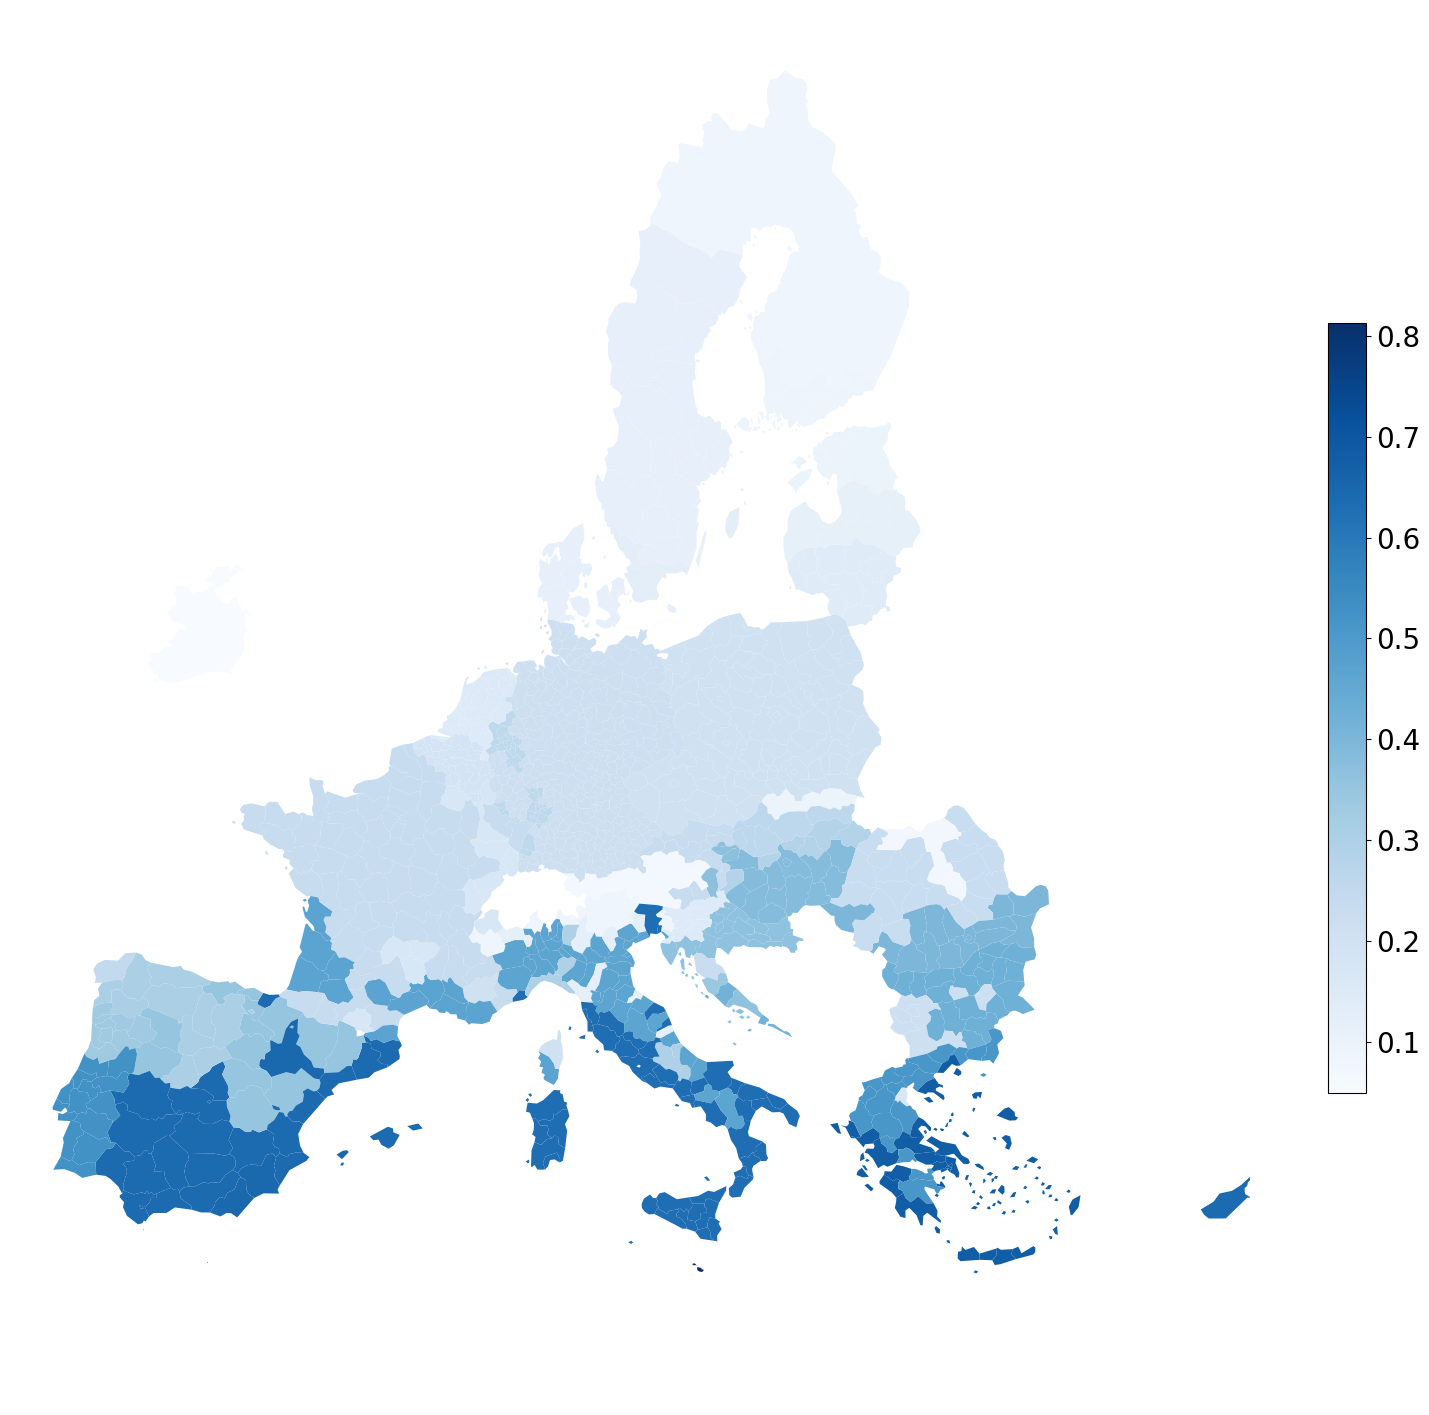

In [11]:
file = 'bld_shr_access_cool_resid_ssp2_rev_nuts.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
if geo==False:
    for i in df.columns.drop(['region_nuts', 'value']):
        hue=i
        sns.histplot(data=df, x='value', hue=hue)
        plt.savefig('plots/'+file[0:8]+hue+'.png')
        plt.show()
        plt.close()
else:
    df = df.groupby(by=['region_nuts'], axis=0).mean(numeric_only=True).reset_index()

    #merging shape with data
    df['NUTS_ID'] = df.region_nuts.str[10:]
    df_gdf = pd.merge(df, nuts, on='NUTS_ID')

    year = 2050
    gdf = gpd.GeoDataFrame(df_gdf)
    col = 'value'
    ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
                #cmap='RdBu_r', 
                cmap='Blues', #inferno_r
                #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
                #norm=custom_norm, 
                edgecolor=None,
                missing_kwds={'color': 'lightgrey'},
                legend_kwds={"shrink":.5},)
    ax.figure.axes[1].tick_params(labelsize=20)
    ax.set_xlim(0.25e7, 0.65e7)
    ax.set_ylim(1e6, 5.5e6)
    ax.set_axis_off()
    plt.savefig('plots/map_'+file[0:8]+'.png')
    plt.show()

## Material demand NUTS0 vs NUTS3
-  (bar chart) – total difference
- (map) geographical distribution, e.g. cities more or less than rural, individual cities more similar to other countries than their own
- (distribution plots) – more exploratory analysis of potential correlates (population size, population trend, economic growth etc.)

In [3]:
mat = pd.read_csv("output/report_STURM_SSP2-baseline_resid_region_bld_material.csv")
mat = mat[mat['region_bld']=='C-WEU-DEU'].groupby(by=['region_bld', 'material', 'year']).sum(numeric_only=True)

<Axes: xlabel='year', ylabel='mat_demand_Mt'>

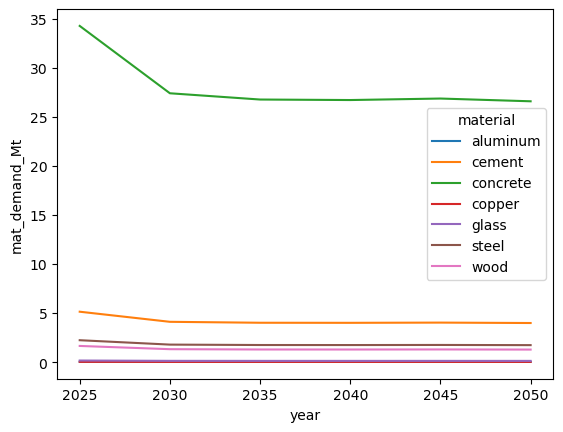

In [7]:
sns.lineplot(data=mat.mat_demand_Mt.reset_index(), x="year", y="mat_demand_Mt", hue='material')

In [9]:
data = mat.groupby(level=[1,2]).sum(numeric_only=True).mat_demand_Mt.reset_index()
#data = data.replace({'SSP2-baseline':'Baseline (SSP2)', 'SSP2-DLS':'Technical potential (Decent Living Standards)', 'SSP2-CCS-dwn':'Current willingness (Circular Consumption Survey)'})
data = data.sort_values(['material', 'year'], ascending=False)
fig = px.line(data, x="year", y="mat_demand_Mt", color="material", labels={"mat_demand_Mt":"Total Annual Material Demand in Germany <br>[Million tonnes]", 'variable':'Land use type', 'index':'year'}, template='simple_white', 
             color_discrete_sequence=px.colors.qualitative.Dark2)
fig.update_layout(width=900, height=500, legend={'traceorder': 'reversed'}) 
#fig.write_image('plots/line_floor_tot_SSP2_Willing_DLS.svg')
fig.write_image('plots/line_mat_demand.png')
fig.show()

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [ ]:
#data
mat = pd.read_csv("output/report_STURM_SSP2-baseline_resid_region_bld_material.csv")
mat = mat.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

mat = pd.concat([mat_bld, mat_dwn, mat_shr], axis=0)

sns.lineplot(data=mat.floor_tot_Mm2.reset_index(), x="year", y="floor_tot_Mm2", hue="region_bld", style="scenario")

<Axes: xlabel='year', ylabel='floor_tot_Mm2'>

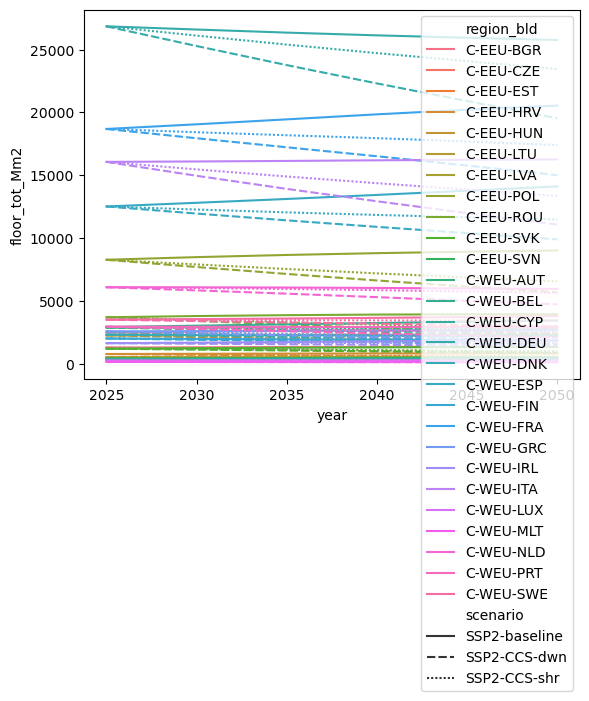

In [ ]:
#data
mat = pd.read_csv("output/report_STURM_SSP2-baseline_resid_region_bld_material.csv")
mat_bld = mat.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

mat = pd.read_csv("output/report_STURM_SSP2-CCS-dwn_resid_region_bld_material.csv")
mat_dwn = mat.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

mat = pd.read_csv("output/report_STURM_SSP2-CCS-shr_resid_region_bld_material.csv")
mat_shr = mat.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

mat = pd.concat([mat_bld, mat_dwn, mat_shr], axis=0)

sns.lineplot(data=mat.floor_tot_Mm2.reset_index(), x="year", y="floor_tot_Mm2", hue="region_bld", style="scenario")

<Axes: xlabel='year', ylabel='floor_tot_Mm2'>

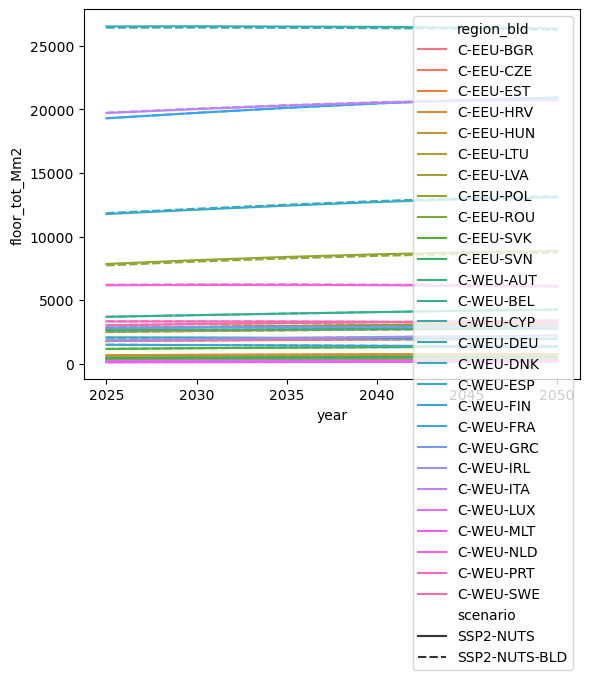

In [2]:
#data
mat = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_material.csv")
mat['region_bld'] = mat.region_nuts.str[0:9]
mat_nuts = mat.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

mat = pd.read_csv("output/report_STURM_SSP2-NUTS-BLD_resid_region_bld_material.csv")
mat_bld = mat.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

mat = pd.concat([mat_nuts, mat_bld], axis=0)

sns.lineplot(data=mat.floor_tot_Mm2.reset_index(), x="year", y="floor_tot_Mm2", hue="region_bld", style="scenario")

In [3]:
#data
mat = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_energy.csv")
mat['region_bld'] = mat.region_nuts.str[0:9]
mat_nuts = mat.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

mat = pd.read_csv("output/report_STURM_SSP2-NUTS-BLD_resid_region_bld_energy.csv")
mat_bld = mat.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

mat = pd.concat([mat_nuts, mat_bld], axis=0)

In [6]:
mat = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_energy.csv")
mat_ = pd.read_csv("output/report_STURM_SSP2-NUTS-BLD_resid_region_bld_energy.csv")

In [7]:
mat_.loc[:,:'floor_Mm2'].sum(axis=0, numeric_only=True)

year        298,937,760.00
stock_M           1,388.45
floor_Mm2       130,003.92
dtype: float64

In [8]:
mat.loc[:,:'floor_Mm2'].sum(axis=0, numeric_only=True)

year        4,509,790,020.00
stock_M             1,389.12
floor_Mm2         130,096.42
dtype: float64

(0.0, 18594.050716628535)

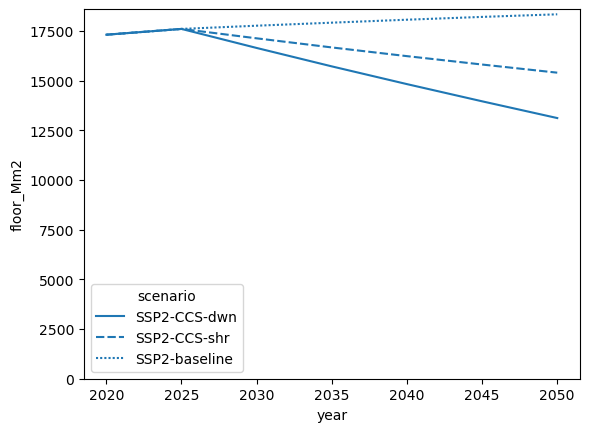

In [18]:
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True).floor_Mm2.reset_index(), x="year", y="floor_Mm2", style="scenario")
ax.set_ylim(bottom=0)

In [22]:
mat.groupby(level=[1,2]).sum(numeric_only=True).stock_M.reset_index()

,scenario,year,stock_M
0,SSP2-CCS-dwn,2020,187.73
1,SSP2-CCS-dwn,2025,188.13
2,SSP2-CCS-dwn,2030,187.21
3,SSP2-CCS-dwn,2035,186.34
4,SSP2-CCS-dwn,2040,185.62
5,SSP2-CCS-dwn,2045,185.01
6,SSP2-CCS-dwn,2050,184.46
7,SSP2-CCS-shr,2020,191.16
8,SSP2-CCS-shr,2025,191.82
9,SSP2-CCS-shr,2030,191.32


<Axes: xlabel='year', ylabel='stock_M'>

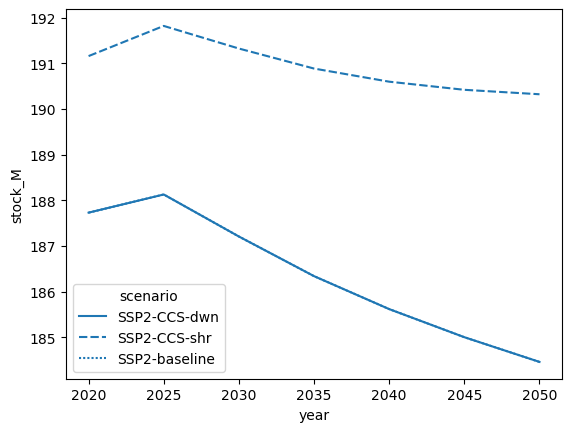

In [23]:
sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True).stock_M.reset_index(), x="year", y="stock_M", style="scenario")

In [20]:
floor_tot_Mm2 = mat.floor_new_Mm2.unstack(1)
floor_tot_Mm2['pc_diff'] = floor_tot_Mm2['SSP2-CCS-dwn'] / floor_tot_Mm2['SSP2-baseline'] 
sns.lineplot(data=floor_tot_Mm2.pc_diff.reset_index(), x="year", y="pc_diff", hue="region_bld")

AttributeError: 'DataFrame' object has no attribute 'floor_new_Mm2'

In [10]:
floor_tot_Mm2 = mat.floor_new_Mm2.unstack(1).groupby(axis=0, level='year').sum()
floor_tot_Mm2['pc_diff'] = floor_tot_Mm2['SSP2-NUTS'] / floor_tot_Mm2['SSP2-NUTS-BLD'] 
sns.lineplot(data=floor_tot_Mm2.pc_diff.reset_index(), x="year", y="pc_diff")

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_83568/593346998.py:1: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  floor_tot_Mm2 = mat.floor_new_Mm2.unstack(1).groupby(axis=0, level='year').sum()


KeyError: 'SSP2-NUTS'

(0.0, 130158.35501639973)

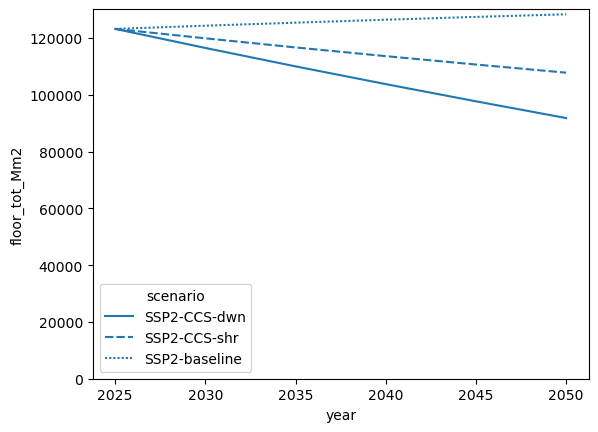

In [11]:
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True).floor_tot_Mm2.reset_index(), x="year", y="floor_tot_Mm2", style="scenario")
ax.set_ylim(bottom=0)

(0.0, 1089.7862410071466)

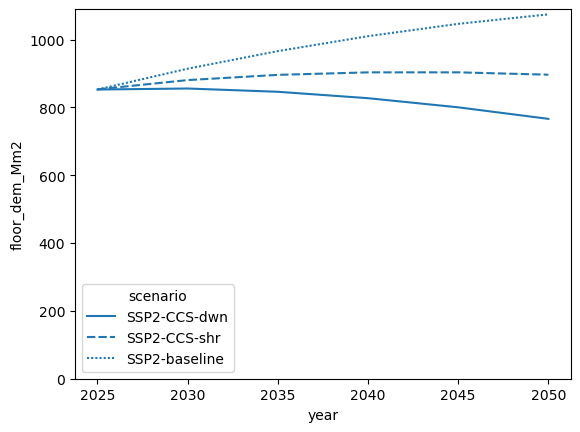

In [12]:
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True).floor_dem_Mm2.reset_index(), x="year", y="floor_dem_Mm2", style="scenario")
ax.set_ylim(bottom=0)

(0.0, 1113.6986743526763)

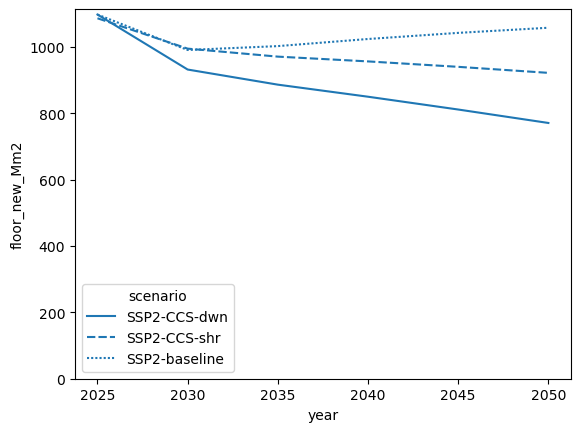

In [13]:
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True).floor_new_Mm2.reset_index(), x="year", y="floor_new_Mm2", style="scenario")
ax.set_ylim(bottom=0)

(0.0, 215.64744662421884)

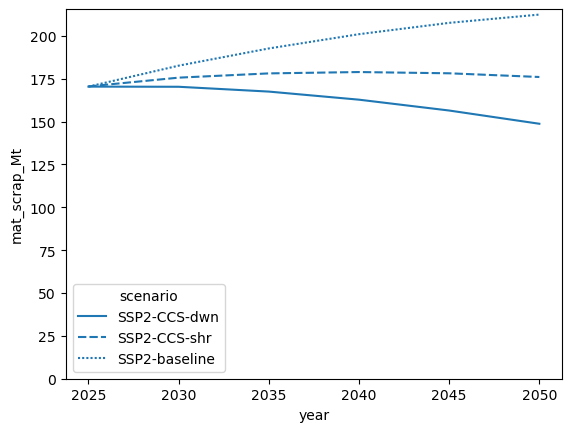

In [14]:
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True).mat_scrap_Mt.reset_index(), x="year", y="mat_scrap_Mt", style="scenario")
ax.set_ylim(bottom=0)

(0.0, 25563.801305537316)

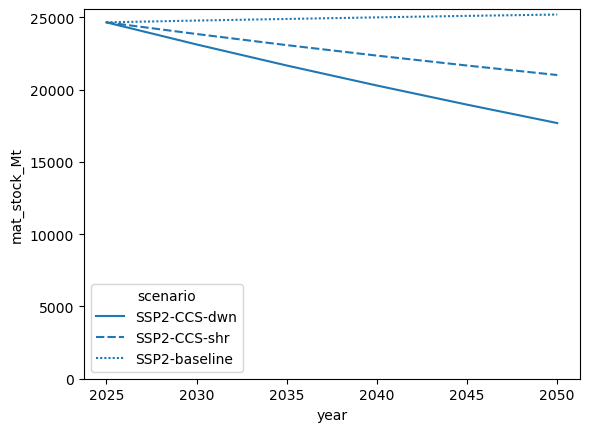

In [15]:
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True).mat_stock_Mt.reset_index(), x="year", y="mat_stock_Mt", style="scenario")
ax.set_ylim(bottom=0)

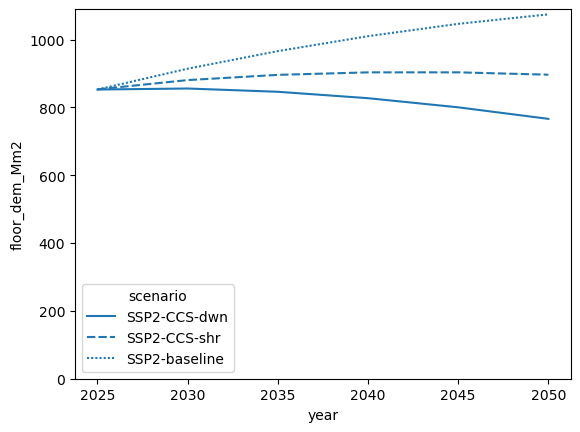

In [16]:
col = "floor_dem_Mm2"
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True)[col].reset_index(), x="year", y=col, style="scenario")
ax.set_ylim(bottom=0)
plt.savefig('plots/lines_'+col+'.png', bbox_inches='tight')

In [13]:
#data import
file = 'hh_size_rev_nuts'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file+".csv")
df2 = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file+"_bld.csv")
pd.concat([df.groupby('year').mean(numeric_only=True), df2.groupby('year').mean(numeric_only=True)], keys=['nuts', 'bld']).unstack()

value                                                                   \
year  2015 2020 2025 2030 2035 2040 2045 2050 2055 2060 2065 2070 2075 2080   
nuts  2.31 2.31 2.31 2.31 2.31 2.31 2.31 2.31 2.31 2.31 2.31 2.31 2.31 2.31   
bld   2.43 2.43 2.44 2.44 2.44 2.44 2.44 2.44 2.44 2.44 2.44 2.44 2.44 2.44   

                          
year 2085 2090 2095 2100  
nuts 2.31 2.31 2.31 2.31  
bld  2.44 2.44 2.44 2.44

In [14]:
#data import
file = 'pop_clim_rev_SSP2_nuts.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)

file = 'pop_clim_rev_SSP2_nuts_bld.csv'
df2 = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
pd.concat([df.groupby('year').sum(numeric_only=True), df2.groupby('year').sum(numeric_only=True)], keys=['nuts', 'bld']).unstack()

value                                                                 \
year   2020   2025   2030   2035   2040   2045   2050   2055   2060   2065   
nuts 450.18 451.92 451.81 451.01 449.64 447.47 444.35 440.33 435.82 431.48   
bld  450.18 451.92 451.81 451.01 449.64 447.47 444.35 440.33 435.82 431.48   

                                                       
year   2070   2075   2080   2085   2090   2095   2100  
nuts 427.82 424.98 422.83 421.29 420.30 419.80 419.59  
bld  427.82 424.98 422.83 421.29 420.30 419.80 419.59

In [14]:
#data
ene = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_energy.csv")
mat = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_material.csv")

#only region and year
ene = ene.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True) #also summing across fuels
mat = mat.groupby(by=['region_nuts', 'year', 'material'], axis=0).sum(numeric_only=True) #also summing across materials

#ene = ene.xs('electricity', level='fuel_cool').xs('gas', level='fuel_heat').reset_index()
mat = mat.xs('concrete', level='material').reset_index()

#normalising all results by population
file = 'pop_clim_rev_SSP2_nuts.csv'
pop = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
pop = pop.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).reset_index()
pop.columns = ['region_nuts', 'year', 'pop_M']
ene = pd.merge(ene, pop, on=['region_nuts', 'year'], how='left')
ene = ene.set_index(['region_nuts','year'])
ene = ene.div(ene['pop_M'], axis=0).reset_index() #per capita
mat = pd.merge(mat, pop, on=['region_nuts', 'year'], how='left')
mat = mat.set_index(['region_nuts','year'])
mat = mat.div(mat['pop_M'], axis=0).reset_index() #per capita

#merging shape with data
ene['NUTS_ID'] = ene.region_nuts.str[10:]
mat['NUTS_ID'] = mat.region_nuts.str[10:]
ene_gdf = pd.merge(ene, nuts, on='NUTS_ID')
mat_gdf = pd.merge(mat, nuts, on='NUTS_ID')

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_31430/3258938189.py:6: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  ene = ene.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True) #also summing across fuels
/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_31430/3258938189.py:7: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  mat = mat.groupby(by=['region_nuts', 'year', 'material'], axis=0).sum(numeric_only=True) #also summing across materials
/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_31430/3258938189.py:15: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  pop = pop.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).reset_index()


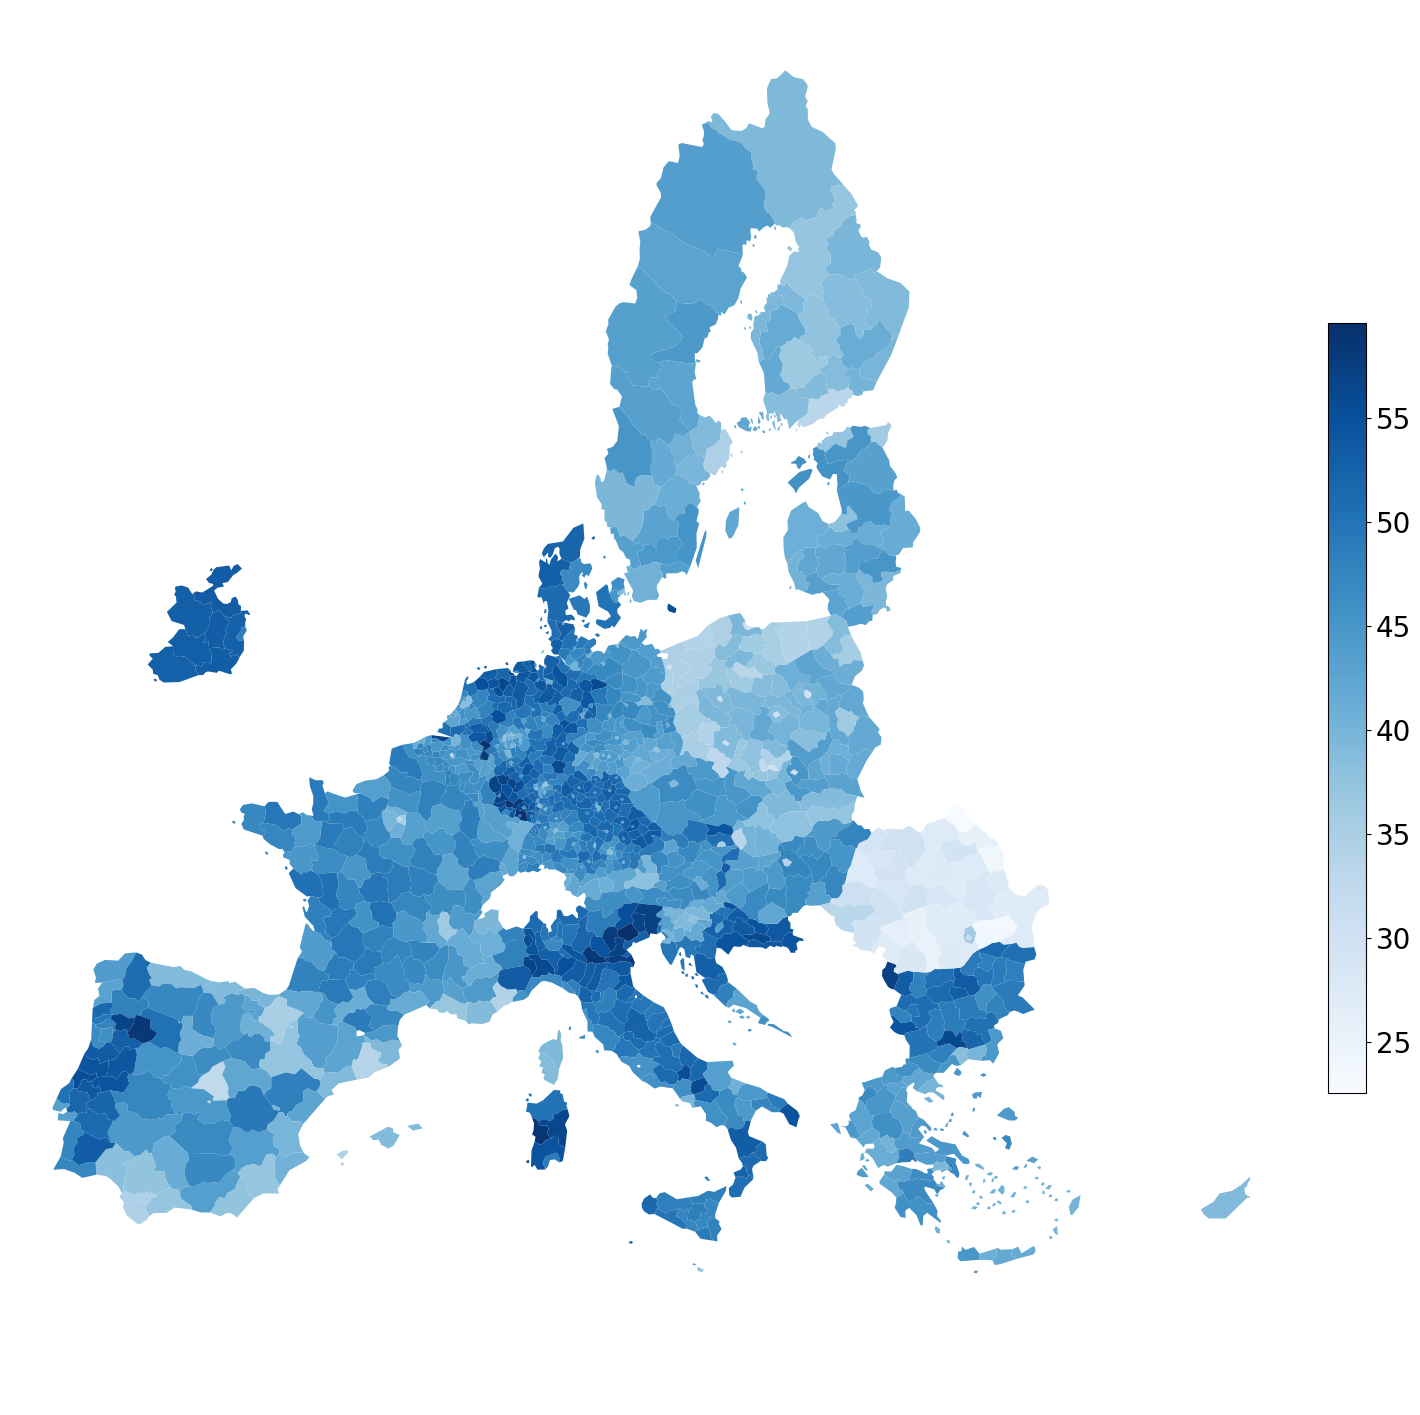

In [43]:
year = 2050
gdf = gpd.GeoDataFrame(ene_gdf[ene_gdf['year']==year])
#gdf = gpd.GeoDataFrame(ene_gdf)
col = 'floor_Mm2' #m2 per cap
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              #cmap='RdBu_r', 
              cmap='Blues', #inferno_r
              #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
              #norm=custom_norm, 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
              legend_kwds={"shrink":.5},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()
plt.savefig('plots/map_'+col+'_'+str(year)+'.png', bbox_inches='tight')

In [11]:

ene = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_energy.csv")
mat = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_material.csv")

#only region and year
ene = ene.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True) #also summing across fuels
mat = mat.groupby(by=['region_nuts', 'year', 'material'], axis=0).sum(numeric_only=True) #also summing across materials

#ene = ene.xs('electricity', level='fuel_cool').xs('gas', level='fuel_heat').reset_index()
mat = mat.xs('concrete', level='material').reset_index()

#normalising all results by population
file = 'pop_clim_rev_SSP2_nuts.csv'
pop = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
pop = pop.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).reset_index()
pop.columns = ['region_nuts', 'year', 'pop_M']
ene = pd.merge(ene, pop, on=['region_nuts', 'year'], how='left')
ene = ene.set_index(['region_nuts','year'])
ene = ene.div(ene['pop_M'], axis=0).reset_index() #per capita
mat = pd.merge(mat, pop, on=['region_nuts', 'year'], how='left')
mat = mat.set_index(['region_nuts','year'])
mat = mat.div(mat['pop_M'], axis=0).reset_index() #per capita

mat = mat.groupby('region_nuts').mean(numeric_only=True).reset_index()

#merging shape with data
ene['NUTS_ID'] = ene.region_nuts.str[10:]
mat['NUTS_ID'] = mat.region_nuts.str[10:]
ene_gdf = pd.merge(ene, nuts, on='NUTS_ID')
mat_gdf = pd.merge(mat, nuts, on='NUTS_ID')



/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_31430/3102442182.py:5: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  ene = ene.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True) #also summing across fuels
/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_31430/3102442182.py:6: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  mat = mat.groupby(by=['region_nuts', 'year', 'material'], axis=0).sum(numeric_only=True) #also summing across materials
/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_31430/3102442182.py:14: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  pop = pop.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).reset_index()


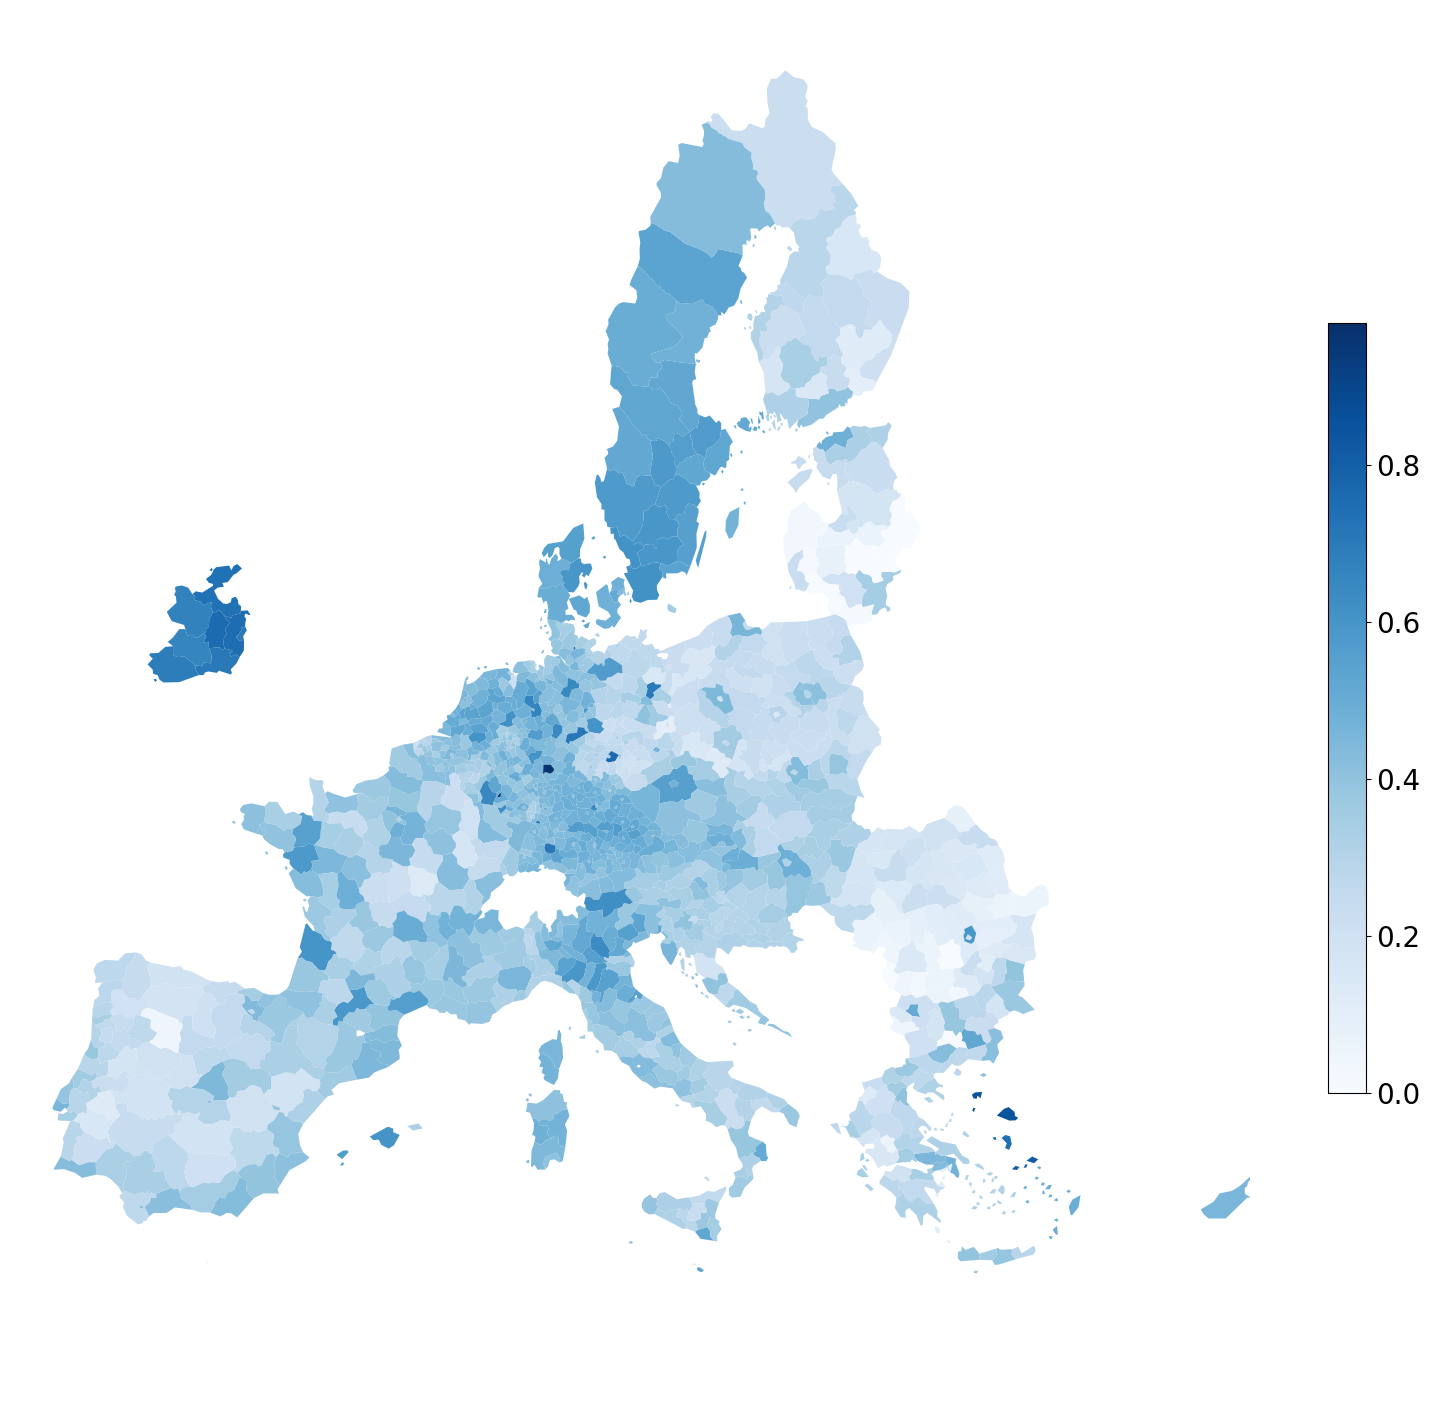

In [12]:
#year = 2050
gdf = gpd.GeoDataFrame(mat_gdf)
#gdf = gpd.GeoDataFrame(ene_gdf)
col = 'floor_new_Mm2' #m2 per cap
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              #cmap='RdBu_r', 
              cmap='Blues', #inferno_r
              #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
              #norm=custom_norm, 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
              legend_kwds={"shrink":.5},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()
plt.savefig('plots/map_'+col+'_'+str(year)+'.png', bbox_inches='tight')

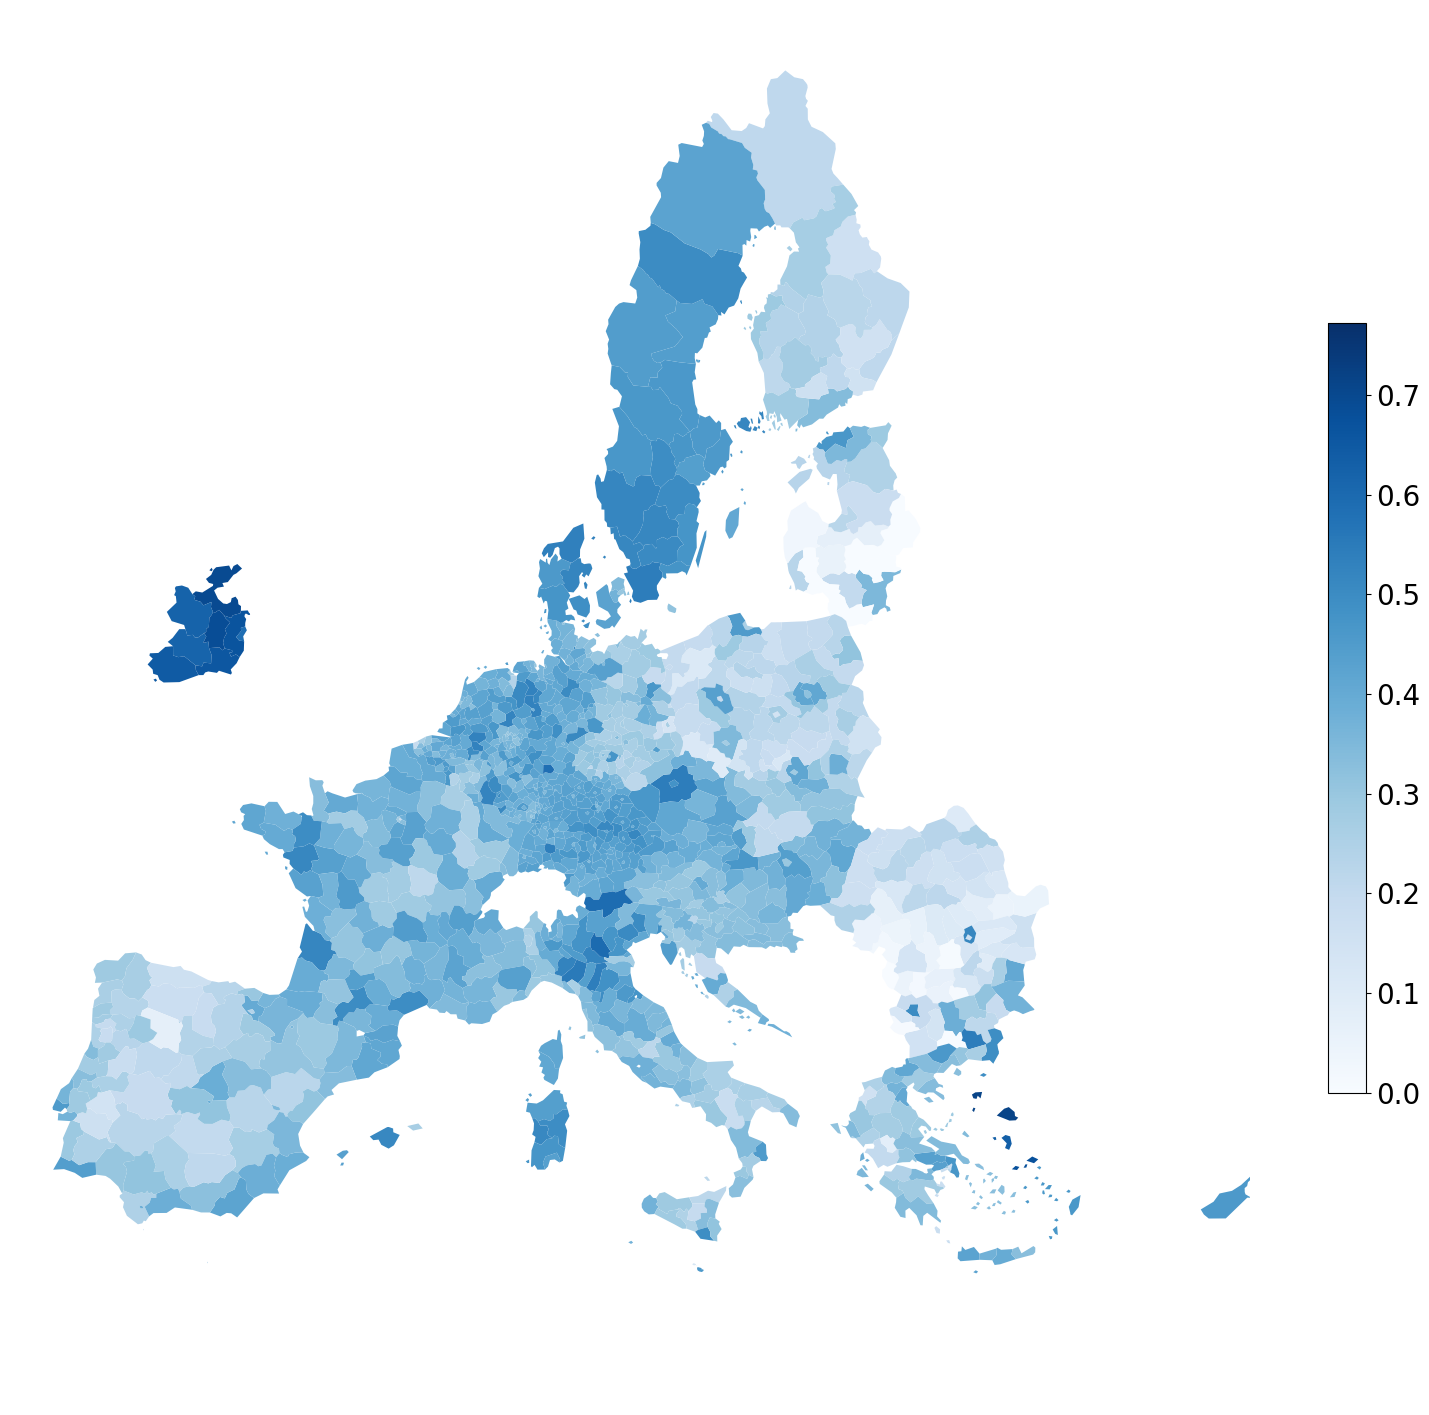

In [6]:
year = 2050
gdf = gpd.GeoDataFrame(mat_gdf[mat_gdf['year']==year])
#gdf = gpd.GeoDataFrame(ene_gdf)
col = 'floor_new_Mm2' #m2 per cap
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              #cmap='RdBu_r', 
              cmap='Blues', #inferno_r
              #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
              #norm=custom_norm, 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
              legend_kwds={"shrink":.5},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()
plt.savefig('plots/map_'+col+'_'+str(year)+'.png', bbox_inches='tight')

In [5]:
ene_gdf

,region_nuts,year,stock_M,floor_Mm2,heat_TJ,cool_TJ,cool_ac_TJ,cool_fans_TJ,hotwater_TJ,other_uses_TJ,pop_M,NUTS_ID,geometry
0,C-EEU-BGR-BG311,2020,0.45,41.11,"14,052.11",70.72,44.74,25.98,"3,046.53",0.00,1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
1,C-EEU-BGR-BG311,2025,0.45,44.05,"14,396.24",88.23,56.12,32.11,"3,361.57",0.00,1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
2,C-EEU-BGR-BG311,2030,0.45,46.93,"14,441.43",102.04,64.40,37.64,"3,629.40",0.00,1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
3,C-EEU-BGR-BG311,2035,0.45,49.70,"14,447.11",113.09,70.47,42.62,"3,856.83",0.00,1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
4,C-EEU-BGR-BG311,2040,0.45,52.34,"14,396.84",123.82,76.16,47.66,"4,027.42",0.00,1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8150,C-WEU-SWE-SE332,2030,0.51,44.28,"27,287.78",29.81,15.37,14.43,"5,043.47",0.00,1.00,SE332,"MULTIPOLYGON (((4969461.836 4802062.392, 49699..."
8151,C-WEU-SWE-SE332,2035,0.51,44.15,"24,410.66",28.82,14.43,14.39,"4,879.14",0.00,1.00,SE332,"MULTIPOLYGON (((4969461.836 4802062.392, 49699..."
8152,C-WEU-SWE-SE332,2040,0.51,44.04,"21,997.37",28.01,13.65,14.36,"4,744.55",0.00,1.00,SE332,"MULTIPOLYGON (((4969461.836 4802062.392, 49699..."
8153,C-WEU-SWE-SE332,2045,0.51,43.92,"19,868.85",27.33,13.02,14.32,"4,633.60",0.00,1.00,SE332,"MULTIPOLYGON (((4969461.836 4802062.392, 49699..."


In [34]:
mat_gdf

,region_nuts,year,floor_tot_Mm2,floor_new_Mm2,floor_dem_Mm2,mat_stock_Mt,mat_demand_Mt,mat_scrap_Mt,mat_int,pop_M,NUTS_ID,geometry
0,C-EEU-BGR-BG311,2025,308.35,0.00,4.17,78.87,0.00,1.01,"4,138,496.95",1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
1,C-EEU-BGR-BG311,2030,328.48,0.00,4.53,84.00,0.00,1.11,"4,577,414.38",1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
2,C-EEU-BGR-BG311,2035,347.91,0.00,4.82,88.94,0.00,1.20,"5,050,031.28",1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
3,C-EEU-BGR-BG311,2040,366.41,0.00,4.96,93.65,0.00,1.25,"5,544,881.30",1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
4,C-EEU-BGR-BG311,2045,383.83,0.00,4.94,98.09,0.00,1.26,"6,039,315.38",1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
...,...,...,...,...,...,...,...,...,...,...,...,...
6985,C-WEU-SWE-SE332,2030,309.95,2.98,3.19,54.93,0.52,0.57,"991,752.30",1.00,SE332,"MULTIPOLYGON (((4969461.836 4802062.392, 49699..."
6986,C-WEU-SWE-SE332,2035,309.08,2.95,3.24,54.73,0.52,0.58,"999,493.55",1.00,SE332,"MULTIPOLYGON (((4969461.836 4802062.392, 49699..."
6987,C-WEU-SWE-SE332,2040,308.25,2.94,3.22,54.55,0.52,0.57,"1,005,437.19",1.00,SE332,"MULTIPOLYGON (((4969461.836 4802062.392, 49699..."
6988,C-WEU-SWE-SE332,2045,307.46,2.97,3.13,54.38,0.52,0.55,"1,008,292.01",1.00,SE332,"MULTIPOLYGON (((4969461.836 4802062.392, 49699..."


In [ ]:
#data
ene = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_energy.csv")
mat = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_material.csv")

#only region and year
ene = ene.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).reset_index() #also summing across fuels
mat = mat.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).reset_index() #also summing across materials

#normalising all results by population
file = 'pop_clim_rev_SSP2_nuts.csv'
pop = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
pop = pop.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).reset_index()
pop.columns = ['region_nuts', 'year', 'pop_M']
ene = pd.merge(ene, pop, on=['region_nuts', 'year'], how='left')
ene = ene.set_index(['region_nuts','year'])
ene = ene.div(ene['pop_M'], axis=0).reset_index() #per capita
mat = pd.merge(mat, pop, on=['region_nuts', 'year'], how='left')
mat = mat.set_index(['region_nuts','year'])
mat = mat.div(mat['pop_M'], axis=0).reset_index() #per capita

#merging shape with data
ene['NUTS_ID'] = ene.region_nuts.str[10:]
mat['NUTS_ID'] = mat.region_nuts.str[10:]
ene_gdf = pd.merge(ene, nuts, on='NUTS_ID')
mat_gdf = pd.merge(mat, nuts, on='NUTS_ID')

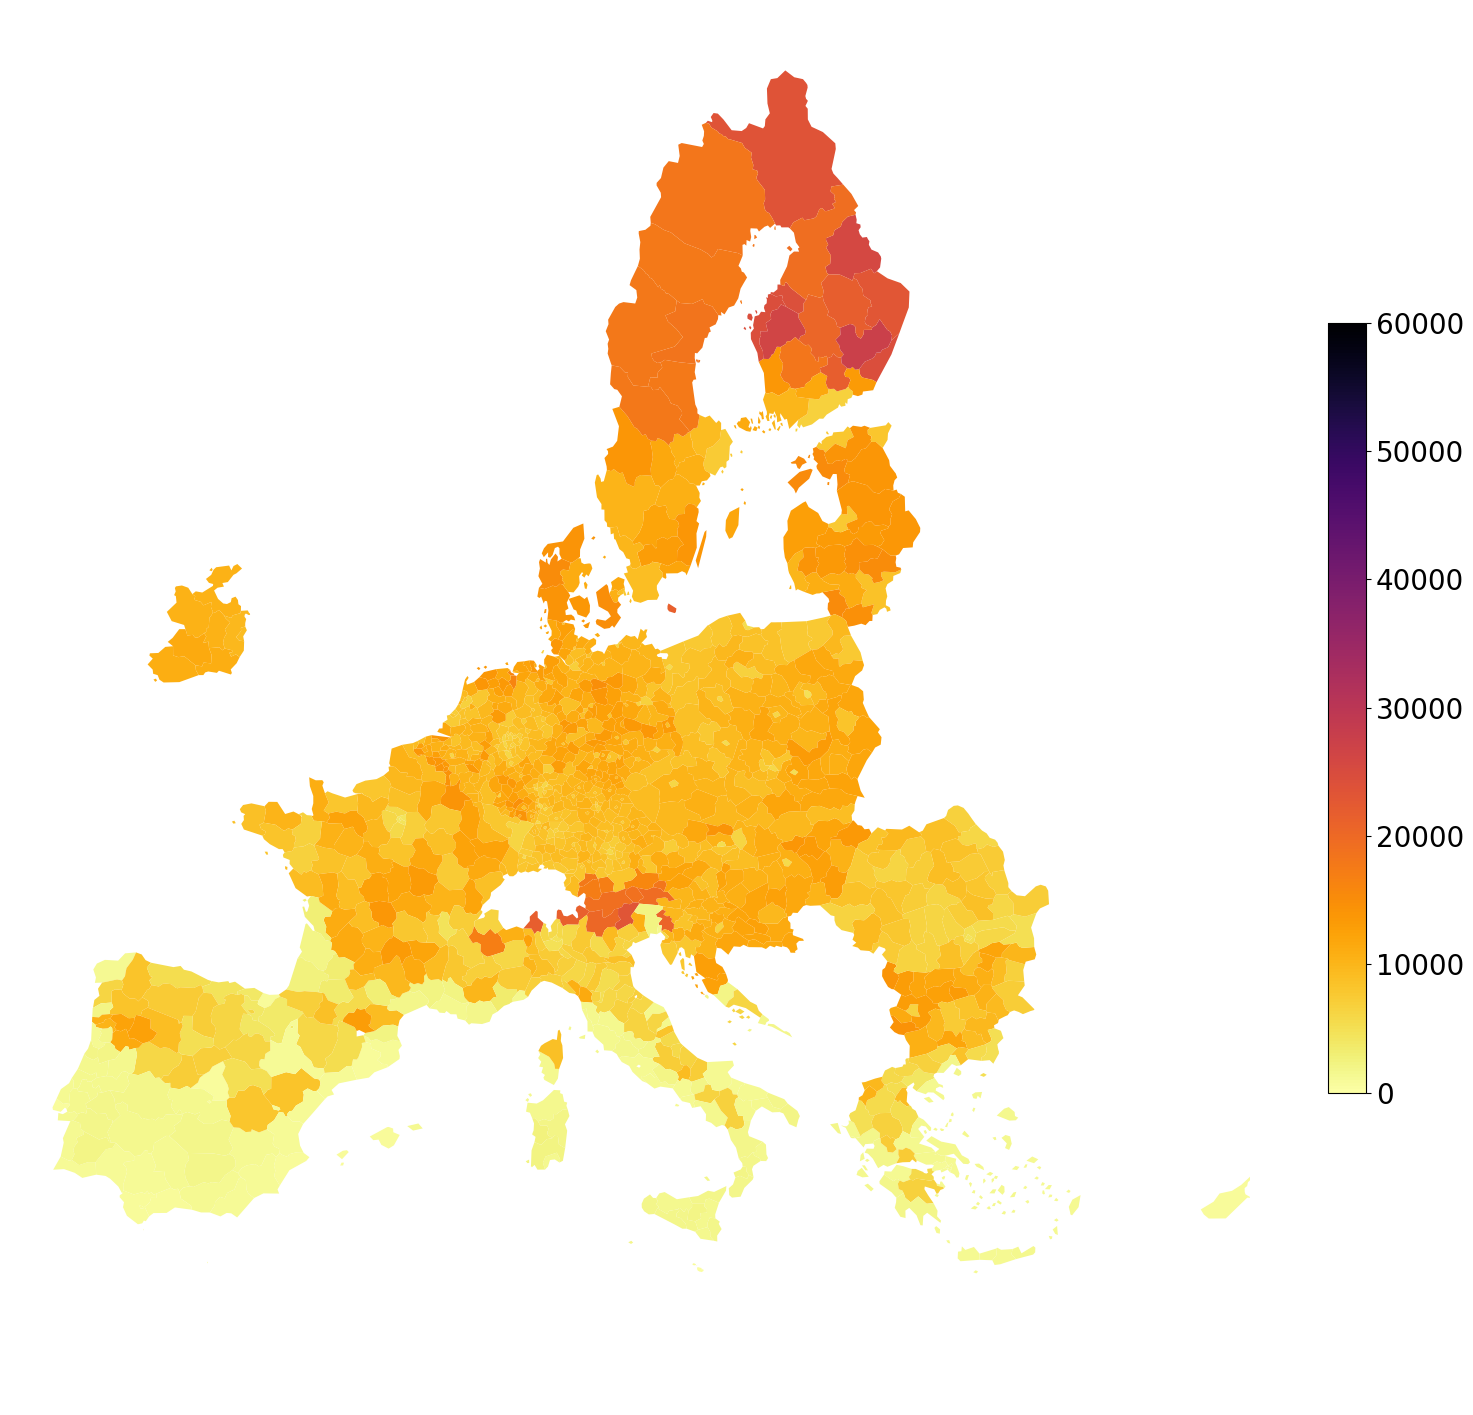

In [12]:
year = 2050
gdf = gpd.GeoDataFrame(ene_gdf[ene_gdf['year']==year])
#gdf = gpd.GeoDataFrame(ene_gdf)
col = 'heat_TJ'
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              #cmap='RdBu_r', 
              cmap='inferno_r', #inferno_r
              #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
              norm=colors.Normalize(vmin=0, vmax=60000), 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
              legend_kwds={"shrink":.5},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()
plt.savefig('plots/map_'+col+'_'+str(year)+'.png', bbox_inches='tight')

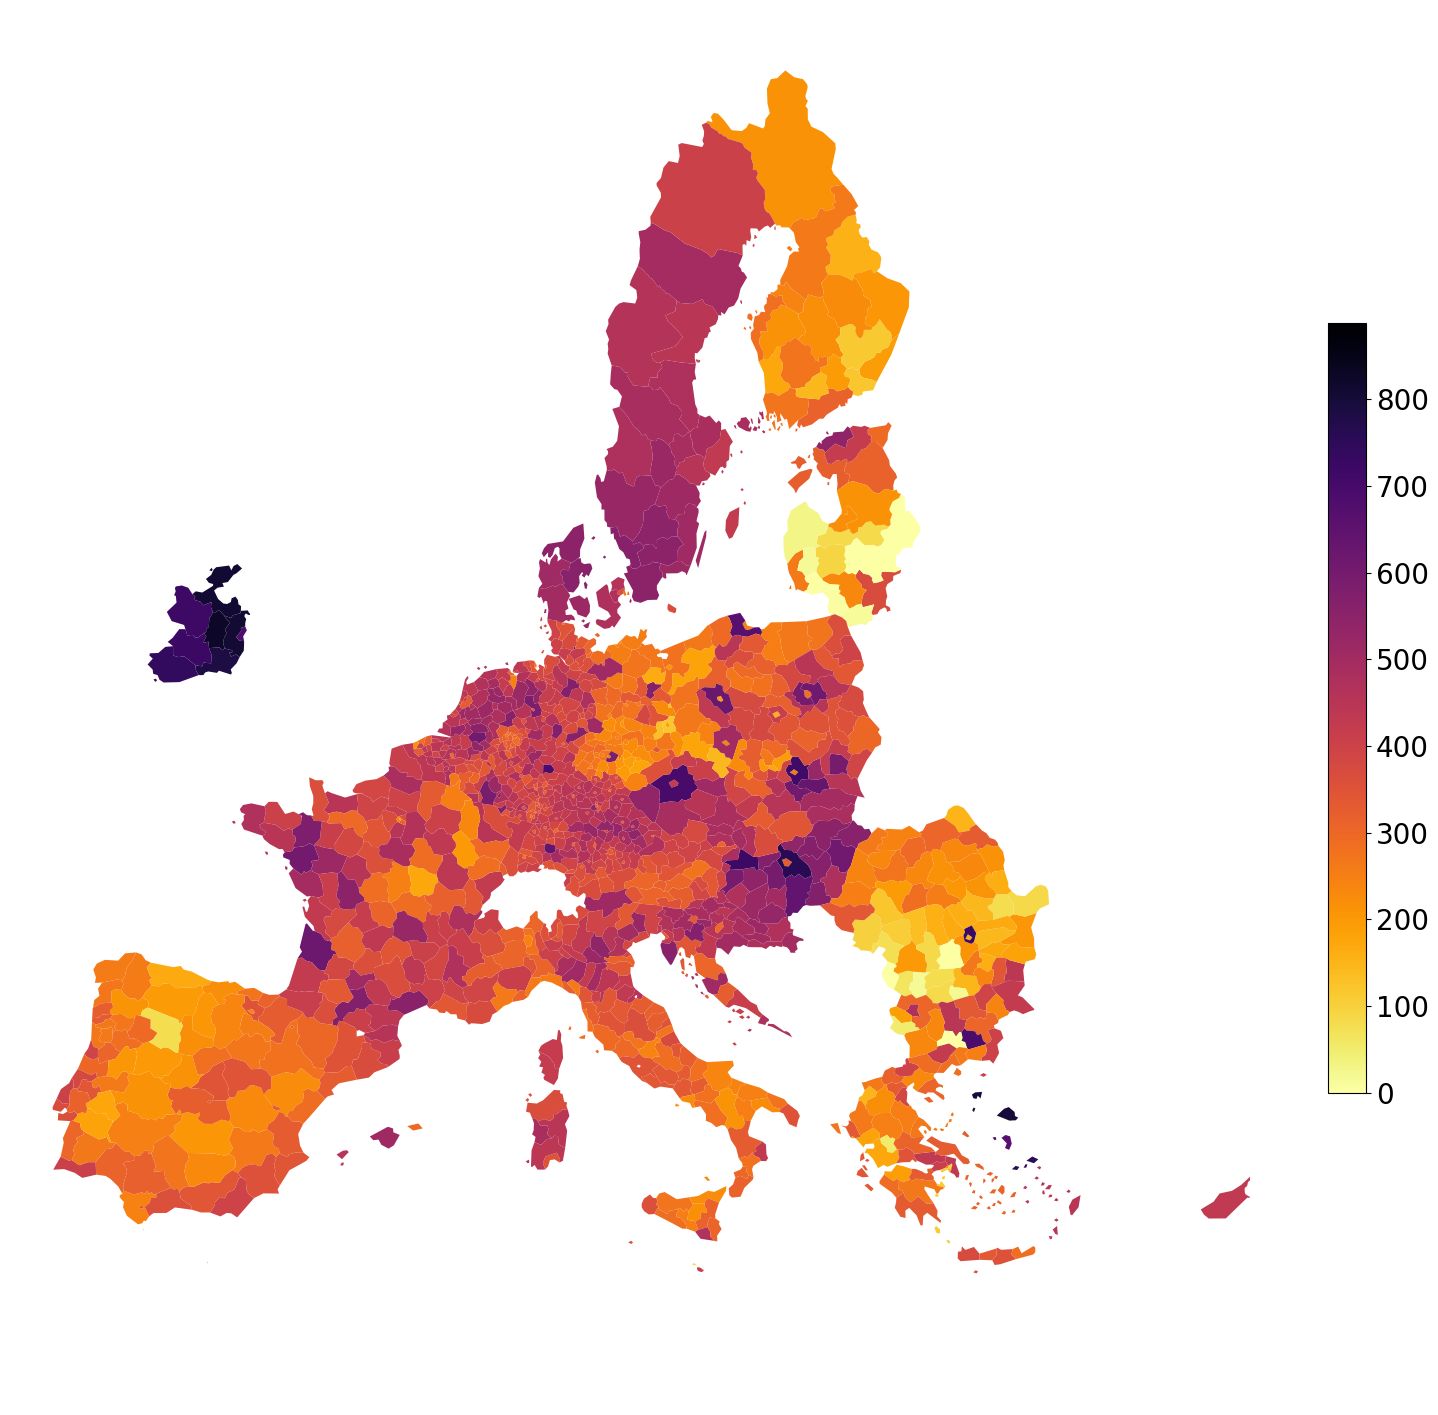

In [19]:
year = 2040
gdf = gpd.GeoDataFrame(mat_gdf[mat_gdf['year']==year])
#gdf = gpd.GeoDataFrame(ene_gdf)
col = 'mat_demand_Mt'
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              #cmap='RdBu_r', 
              cmap='inferno_r', #inferno_r
              #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
              #norm=colors.Normalize(vmin=0, vmax=1.5), 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
              legend_kwds={"shrink":.5},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()
plt.savefig('plots/map_'+col+'_'+str(year)+'.png', bbox_inches='tight')

## Components of material demand 
- floor area, material intensity & population trend
- (scatterplots with material demand) -to what extend do each of the components correlate with material demand (and are mechanically linked via the model)


## Construction demand Baseline vs. CCS

- total difference in housing stocks? #stock_M --> we would assume sharing to only affect new construction and maintain initial stocks, whereas moving assumes to free up stocks

In [ ]:
scenarios = {"-NUTS":"region_nuts", "-NUTS-BLD":"region_bld", "-NUTS-BLD-FLAT":"region_bld"} #["-baseline", "-CCS-dwn", "-CCS-dwn-cutoff", "-DLS"]#["-NUTS-BLD", "-NUTS-BLD-DLS", "-NUTS-BLD-CCS-dwn", "-NUTS-BLD-CCS-dwn-uniform", "-NUTS-BLD-CCS-dwn-high", "-NUTS-BLD-CCS-shr", "-NUTS-BLD-CCS-shr-uniform", "-NUTS-BLD-CCS-mov", "-NUTS-BLD-CCS-mov-uniform",]

mat = pd.read_csv("output/report_STURM_SSP2"+list(scenarios.keys())[0]+"_resid_"+list(scenarios.values())[0]+"_material.csv")
mat = mat[mat['material']=='aluminum'].groupby(by=['region_nuts', 'scenario', 'year']).sum(numeric_only=True)

#normalising all results by population
file = 'pop_clim_rev_SSP2_nuts.csv'
pop = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
pop = pop.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).reset_index()
pop.columns = ['region_nuts', 'year', 'pop_M']
mat = pd.merge(mat, pop, on=['region_nuts', 'year'], how='left')
mat = mat.set_index(['region_nuts','year'])
mat = mat.div(mat['pop_M'], axis=0).reset_index() #per capita

mat = mat.groupby('region_nuts').mean(numeric_only=True).reset_index()

mat['NUTS_ID'] = mat.region_nuts.str[10:]
mat_gdf = pd.merge(mat, nuts, on='NUTS_ID')

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_89886/343176891.py:9: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  pop = pop.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).reset_index()


In [ ]:
scenarios = {"-NUTS":"region_nuts", "-NUTS-BLD":"region_bld", "-NUTS-BLD-FLAT":"region_bld"} #["-baseline", "-CCS-dwn", "-CCS-dwn-cutoff", "-DLS"]#["-NUTS-BLD", "-NUTS-BLD-DLS", "-NUTS-BLD-CCS-dwn", "-NUTS-BLD-CCS-dwn-uniform", "-NUTS-BLD-CCS-dwn-high", "-NUTS-BLD-CCS-shr", "-NUTS-BLD-CCS-shr-uniform", "-NUTS-BLD-CCS-mov", "-NUTS-BLD-CCS-mov-uniform",]

mat = pd.read_csv("output/report_STURM_SSP2"+list(scenarios.keys())[2]+"_resid_"+list(scenarios.values())[2]+"_material.csv")
mat = mat[mat['material']=='aluminum'].groupby(by=['region_bld', 'scenario']).sum(numeric_only=True)
mat['BLD_ID'] = mat.region_bld.str[10:]
nuts['BLD_ID'] = nuts.NUTS_ID.str[2:]
mat_gdf = pd.merge(mat, nuts, on='NUTS_ID')

gdf = gpd.GeoDataFrame(mat_gdf)
col = 'floor_new_Mm2' #m2 per cap
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              #cmap='RdBu_r', 
              cmap='Purples', #inferno_r
              norm=colors.LogNorm(vmin=0.01, vmax=gdf[col].max()),
              #norm=custom_norm, 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
              legend_kwds={"shrink":.5},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()

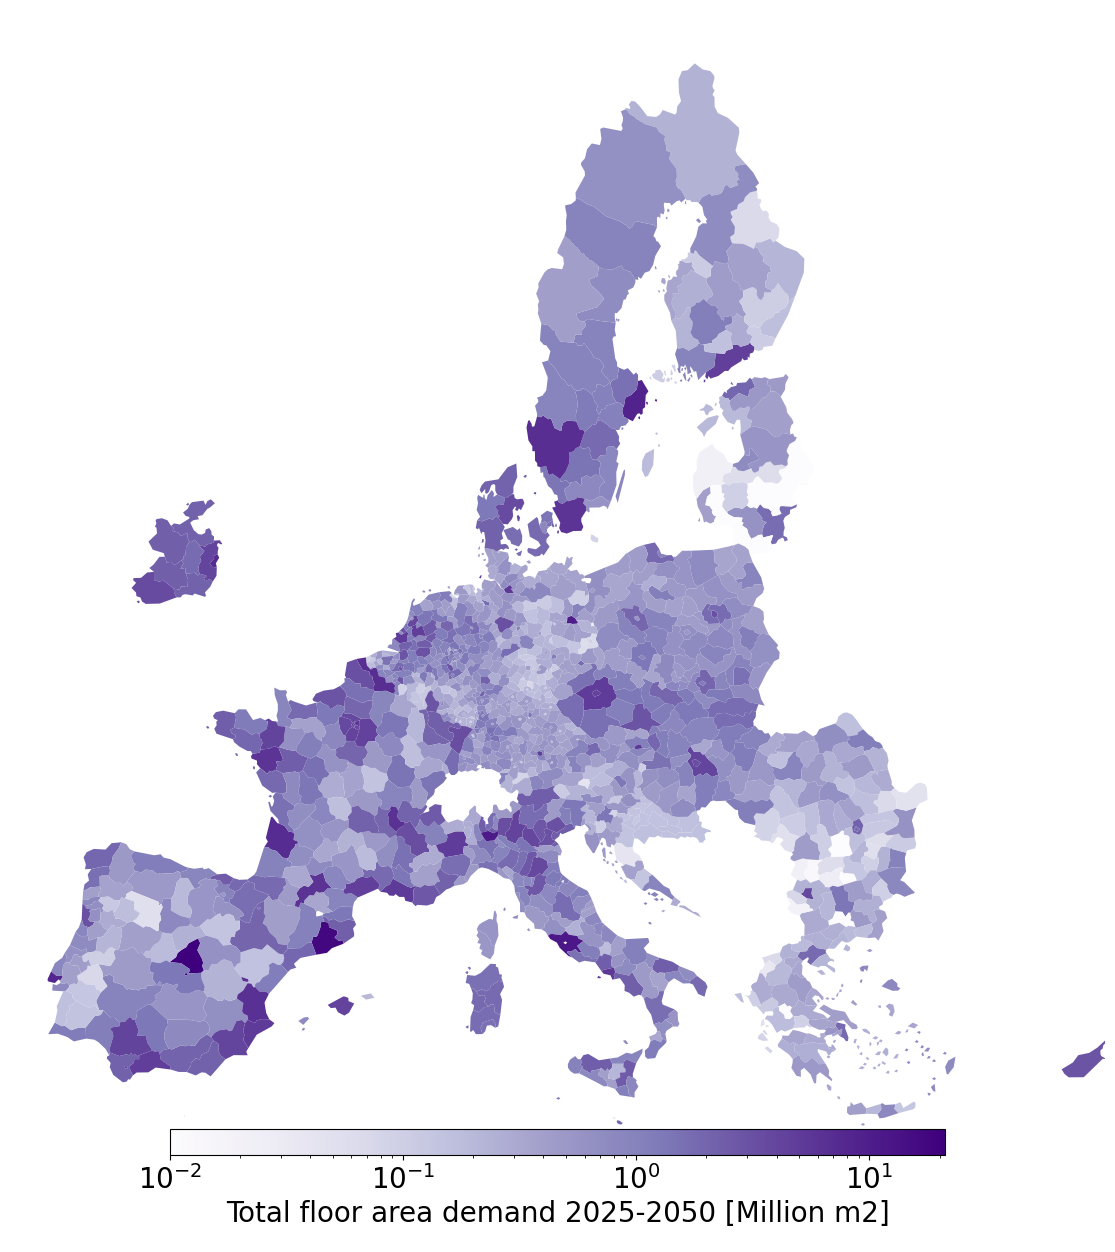

In [18]:
scenarios = {"-NUTS":"region_nuts", "-NUTS-BLD":"region_bld", "-NUTS-BLD-FLAT":"region_bld"} #["-baseline", "-CCS-dwn", "-CCS-dwn-cutoff", "-DLS"]#["-NUTS-BLD", "-NUTS-BLD-DLS", "-NUTS-BLD-CCS-dwn", "-NUTS-BLD-CCS-dwn-uniform", "-NUTS-BLD-CCS-dwn-high", "-NUTS-BLD-CCS-shr", "-NUTS-BLD-CCS-shr-uniform", "-NUTS-BLD-CCS-mov", "-NUTS-BLD-CCS-mov-uniform",]

mat = pd.read_csv("output/report_STURM_SSP2"+list(scenarios.keys())[0]+"_resid_"+list(scenarios.values())[0]+"_material.csv")
mat = mat[mat['material']=='aluminum'].groupby(by=['region_nuts', 'scenario']).sum(numeric_only=True).reset_index()
mat['NUTS_ID'] = mat.region_nuts.str[10:]
mat_gdf = pd.merge(mat, nuts, on='NUTS_ID')

gdf = gpd.GeoDataFrame(mat_gdf)
col = 'floor_new_Mm2' #m2 per cap
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              #cmap='RdBu_r', 
              cmap='Purples', #inferno_r
              norm=colors.LogNorm(vmin=0.01, vmax=gdf[col].max()),
              #norm=custom_norm, 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
              legend_kwds={"shrink":.5, 
                           "orientation":"horizontal",
                           "fraction":0.2,
                           "aspect":30,
                           "pad":0,
                           "anchor":(0.5, 1.4)},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.figure.axes[1].set_xlabel(xlabel='Total floor area demand 2025-2050 [Million m2]', size=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()
plt.savefig('plots/map_'+col+'_2025-2050.png', bbox_inches='tight')

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_89886/293681410.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mat_gdf_nuts['region_bld'] = mat_gdf_nuts.region_nuts.str[0:9]


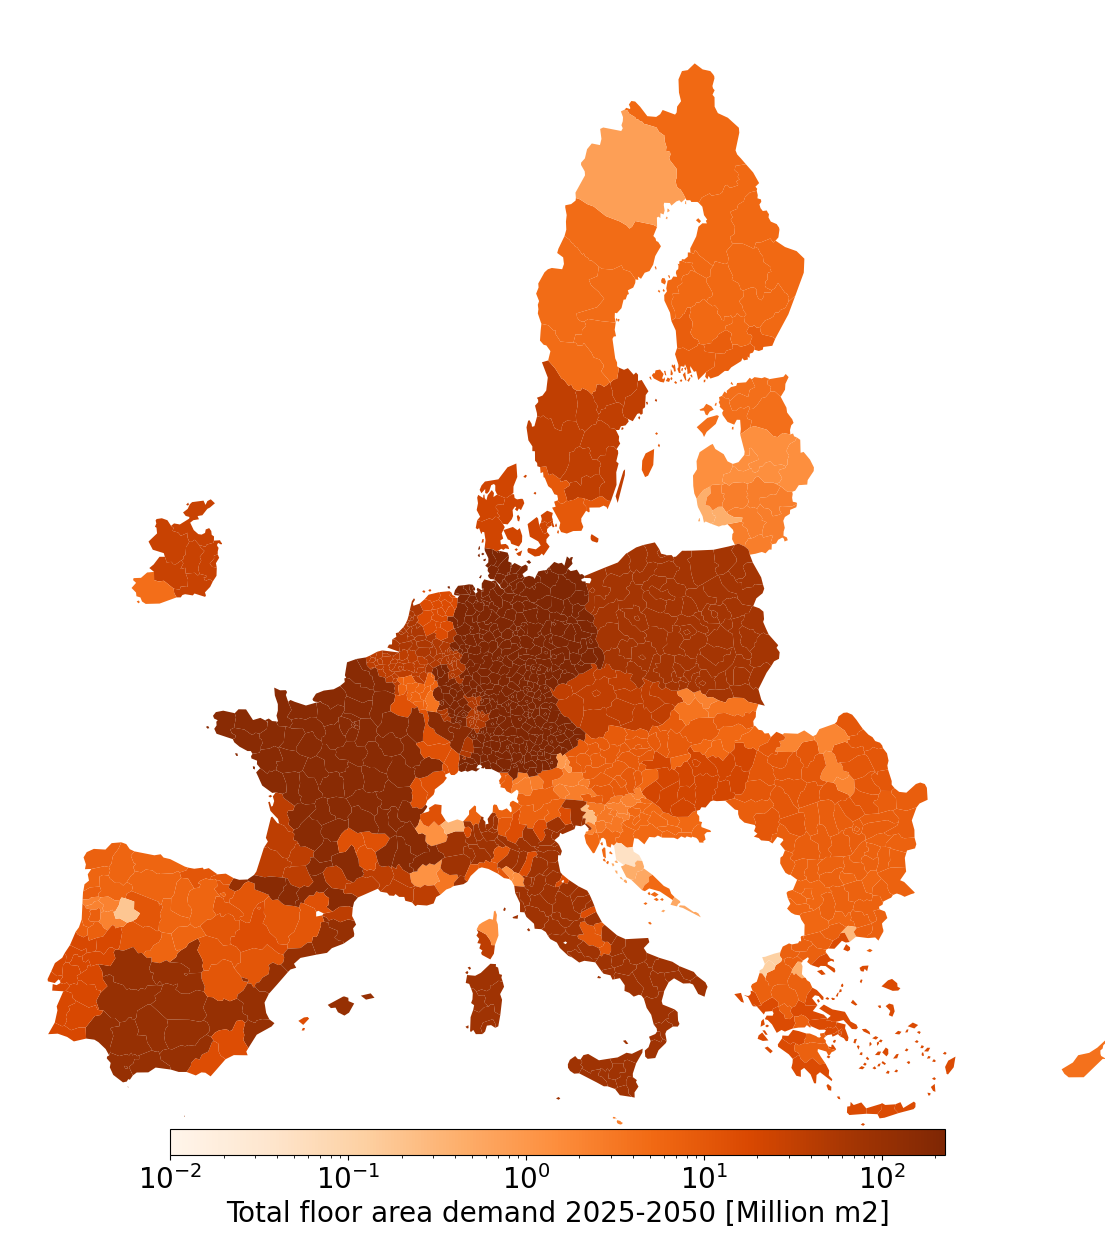

In [28]:
scenarios = {"-NUTS":"region_nuts", "-NUTS-BLD":"region_bld", "-NUTS-BLD-FLAT":"region_bld"} #["-baseline", "-CCS-dwn", "-CCS-dwn-cutoff", "-DLS"]#["-NUTS-BLD", "-NUTS-BLD-DLS", "-NUTS-BLD-CCS-dwn", "-NUTS-BLD-CCS-dwn-uniform", "-NUTS-BLD-CCS-dwn-high", "-NUTS-BLD-CCS-shr", "-NUTS-BLD-CCS-shr-uniform", "-NUTS-BLD-CCS-mov", "-NUTS-BLD-CCS-mov-uniform",]

mat = pd.read_csv("output/report_STURM_SSP2"+list(scenarios.keys())[0]+"_resid_"+list(scenarios.values())[0]+"_material.csv")
mat = mat[mat['material']=='aluminum'].groupby(by=['region_nuts', 'scenario']).sum(numeric_only=True).reset_index()
mat['NUTS_ID'] = mat.region_nuts.str[10:]
mat_gdf = pd.merge(mat, nuts, on='NUTS_ID')

mat_gdf_nuts = mat_gdf[['region_nuts', 'geometry']]

mat = pd.read_csv("output/report_STURM_SSP2"+list(scenarios.keys())[1]+"_resid_"+list(scenarios.values())[1]+"_material.csv")
mat = mat[mat['material']=='aluminum'].groupby(by=['region_bld', 'clim', 'scenario']).sum(numeric_only=True)
mat_gdf_nuts['region_bld'] = mat_gdf_nuts.region_nuts.str[0:9]
clim = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
clim = clim[['region_nuts', 'clim']].drop_duplicates()
mat_gdf_nuts = mat_gdf_nuts.merge(clim, on='region_nuts', how='left')
mat_gdf_nuts = mat_gdf_nuts.merge(mat.reset_index(), on=['region_bld', 'clim'], how='left')

gdf = gpd.GeoDataFrame(mat_gdf_nuts)
col = 'floor_new_Mm2' #m2 per cap
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              cmap='Oranges', #inferno_r
              norm=colors.LogNorm(vmin=0.01, vmax=gdf[col].max()),
              #norm=custom_norm, 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
              legend_kwds={"shrink":.5, 
                           "orientation":"horizontal",
                           "fraction":0.2,
                           "aspect":30,
                           "pad":0,
                           "anchor":(0.5, 1.4)},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.figure.axes[1].set_xlabel(xlabel='Total floor area demand 2025-2050 [Million m2]', size=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()
plt.savefig('plots/map_'+col+'_2025-2050_bld_clim.png', bbox_inches='tight')

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_89886/2542210246.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mat_gdf_nuts['region_bld'] = mat_gdf_nuts.region_nuts.str[0:9]


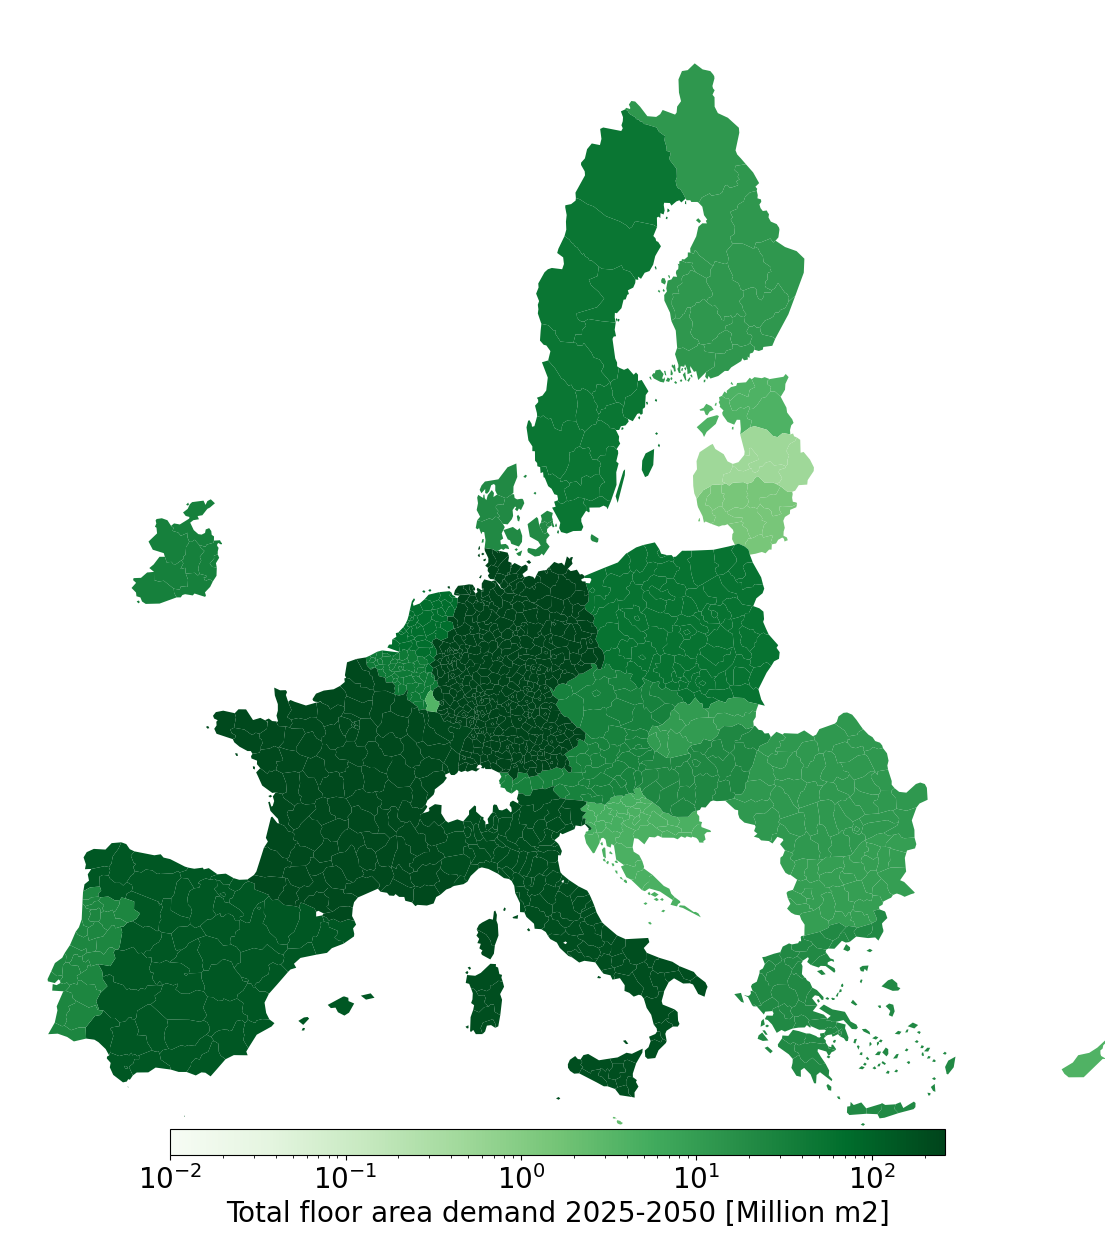

In [20]:
mat_gdf_nuts = mat_gdf[['region_nuts', 'geometry']]
scenarios = {"-NUTS":"region_nuts", "-NUTS-BLD":"region_bld", "-NUTS-BLD-FLAT":"region_bld"} #["-baseline", "-CCS-dwn", "-CCS-dwn-cutoff", "-DLS"]#["-NUTS-BLD", "-NUTS-BLD-DLS", "-NUTS-BLD-CCS-dwn", "-NUTS-BLD-CCS-dwn-uniform", "-NUTS-BLD-CCS-dwn-high", "-NUTS-BLD-CCS-shr", "-NUTS-BLD-CCS-shr-uniform", "-NUTS-BLD-CCS-mov", "-NUTS-BLD-CCS-mov-uniform",]

mat = pd.read_csv("output/report_STURM_SSP2"+list(scenarios.keys())[2]+"_resid_"+list(scenarios.values())[2]+"_material.csv")
mat = mat[mat['material']=='aluminum'].groupby(by=['region_bld', 'scenario']).sum(numeric_only=True)
mat_gdf_nuts['region_bld'] = mat_gdf_nuts.region_nuts.str[0:9]
mat_gdf_nuts = mat_gdf_nuts.merge(mat.reset_index(), on='region_bld', how='left')

gdf = gpd.GeoDataFrame(mat_gdf_nuts)
col = 'floor_new_Mm2' #m2 per cap
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              #cmap='RdBu_r', 
              cmap='Greens', #inferno_r
              norm=colors.LogNorm(vmin=0.01, vmax=gdf[col].max()),
              #norm=custom_norm, 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
              legend_kwds={"shrink":.5, 
                           "orientation":"horizontal",
                           "fraction":0.2,
                           "aspect":30,
                           "pad":0,
                           "anchor":(0.5, 1.4)},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.figure.axes[1].set_xlabel(xlabel='Total floor area demand 2025-2050 [Million m2]', size=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()
plt.savefig('plots/map_'+col+'_2025-2050_bld.png', bbox_inches='tight')

In [32]:
mat

,region_bld,region_nuts,m2_per_cap,pop_trend,pop,m2_per_cap_suff,m2_excess,pop_new,m2_demand_new,scaling,m2_per_cap_suff_match,m2_per_cap_weighted,m2_per_cap_suff_match_weighted,NUTS_ID
0,C-EEU-BGR,C-EEU-BGR-BG311,45.02,-0.33,0.08,113.58,"2,114,129.40",-0.03,0.00,0.00,0.00,3.61,0.00,BG311
1,C-EEU-BGR,C-EEU-BGR-BG312,41.90,-0.24,0.12,112.15,"2,756,815.34",-0.03,0.00,0.00,0.00,4.91,0.00,BG312
2,C-EEU-BGR,C-EEU-BGR-BG313,38.00,-0.23,0.15,110.29,"2,915,905.66",-0.03,0.00,0.00,0.00,5.57,0.00,BG313
3,C-EEU-BGR,C-EEU-BGR-BG314,40.23,-0.16,0.23,111.19,"5,054,241.23",-0.04,0.00,0.00,0.00,9.36,0.00,BG314
4,C-EEU-BGR,C-EEU-BGR-BG315,40.73,-0.20,0.12,110.18,"2,725,817.74",-0.02,0.00,0.00,0.00,4.90,0.00,BG315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1160,C-WEU-SWE,C-WEU-SWE-SE313,47.05,0.05,0.28,120.43,"7,532,012.52",0.01,"253,273.82",9.23,46.14,13.05,12.79,SE313
1161,C-WEU-SWE,C-WEU-SWE-SE321,49.10,0.04,0.23,120.63,"6,675,498.26",0.01,"188,488.76",9.68,48.28,11.23,11.04,SE321
1162,C-WEU-SWE,C-WEU-SWE-SE322,48.13,0.01,0.12,121.16,"3,475,293.44",0.00,"20,999.75",9.46,47.96,5.92,5.90,SE322
1163,C-WEU-SWE,C-WEU-SWE-SE331,45.00,0.07,0.26,119.18,"6,589,082.83",0.02,"368,906.70",13.19,43.59,11.76,11.39,SE331


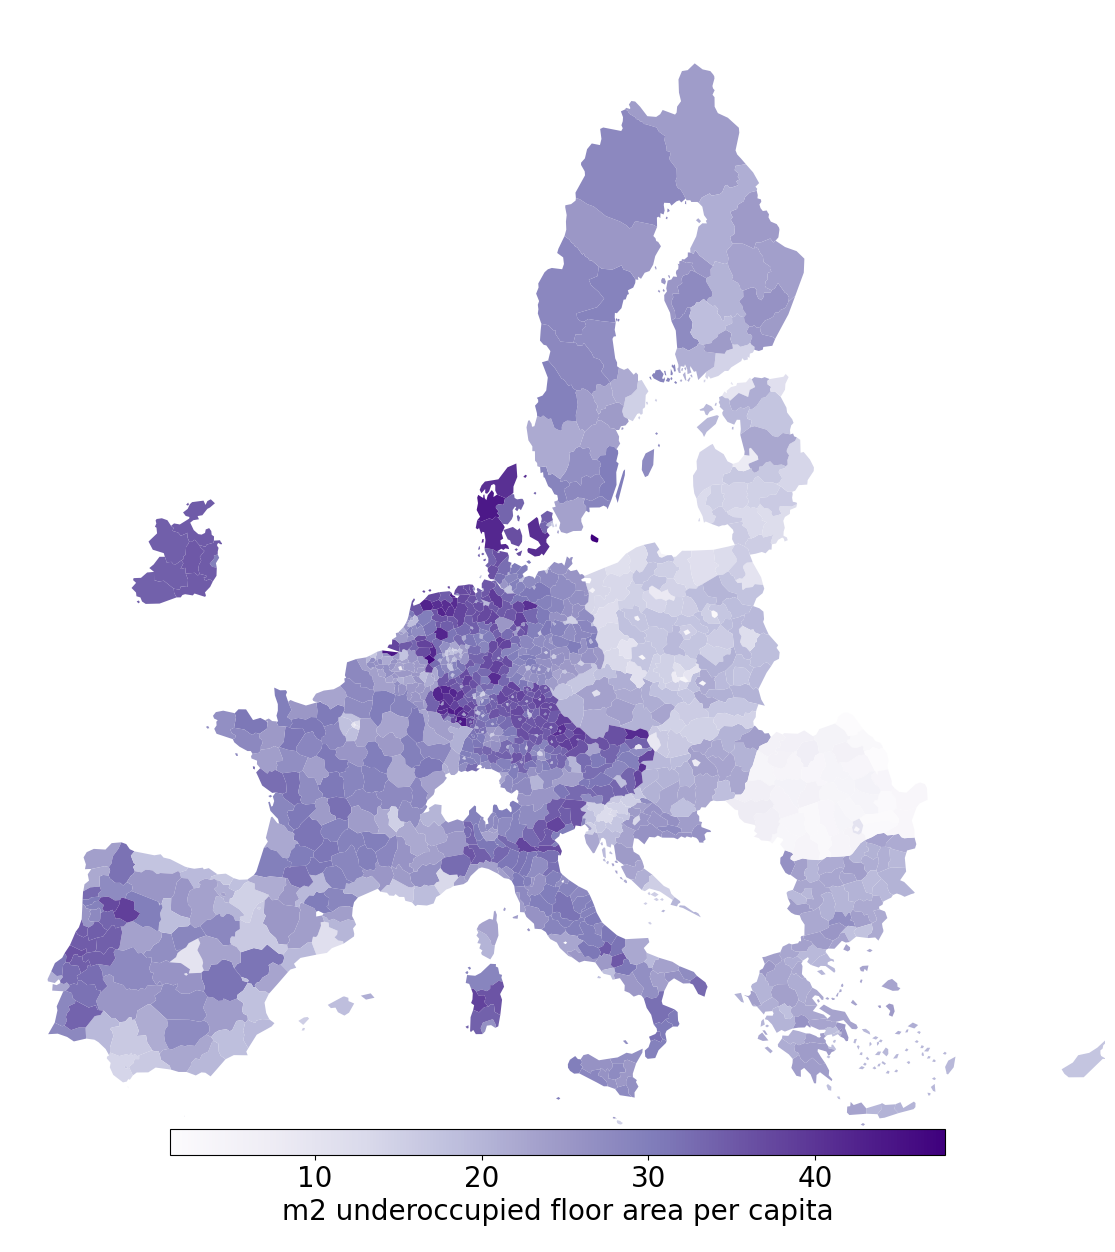

In [44]:
mat = pd.read_csv('/Users/Mira/Desktop/MCC/Code/EUBUCCO-IAM/underoccupancy_excess_demand_2025-2050.csv')
mat['NUTS_ID'] = mat.region_nuts.str[10:]
mat['m2_excess_per_cap'] = (mat['m2_excess']/(mat['pop']*1e6)).replace([np.inf, -np.inf, 0], np.nan)
mat_gdf = pd.merge(mat, nuts, on='NUTS_ID')

gdf = gpd.GeoDataFrame(mat_gdf.replace(0, np.nan))
col = 'm2_excess_per_cap' #m2 per cap
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              #cmap='RdBu_r', 
              cmap='Purples', #inferno_r
              #norm=colors.LogNorm(vmin=0.01, vmax=gdf[col].max()),
              #norm=custom_norm, 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
              legend_kwds={"shrink":.5, 
                           "orientation":"horizontal",
                           "fraction":0.2,
                           "aspect":30,
                           "pad":0,
                           "anchor":(0.5, 1.4)},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.figure.axes[1].set_xlabel(xlabel='m2 underoccupied floor area per capita', size=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()
plt.savefig('plots/map_'+col+'.png', bbox_inches='tight')

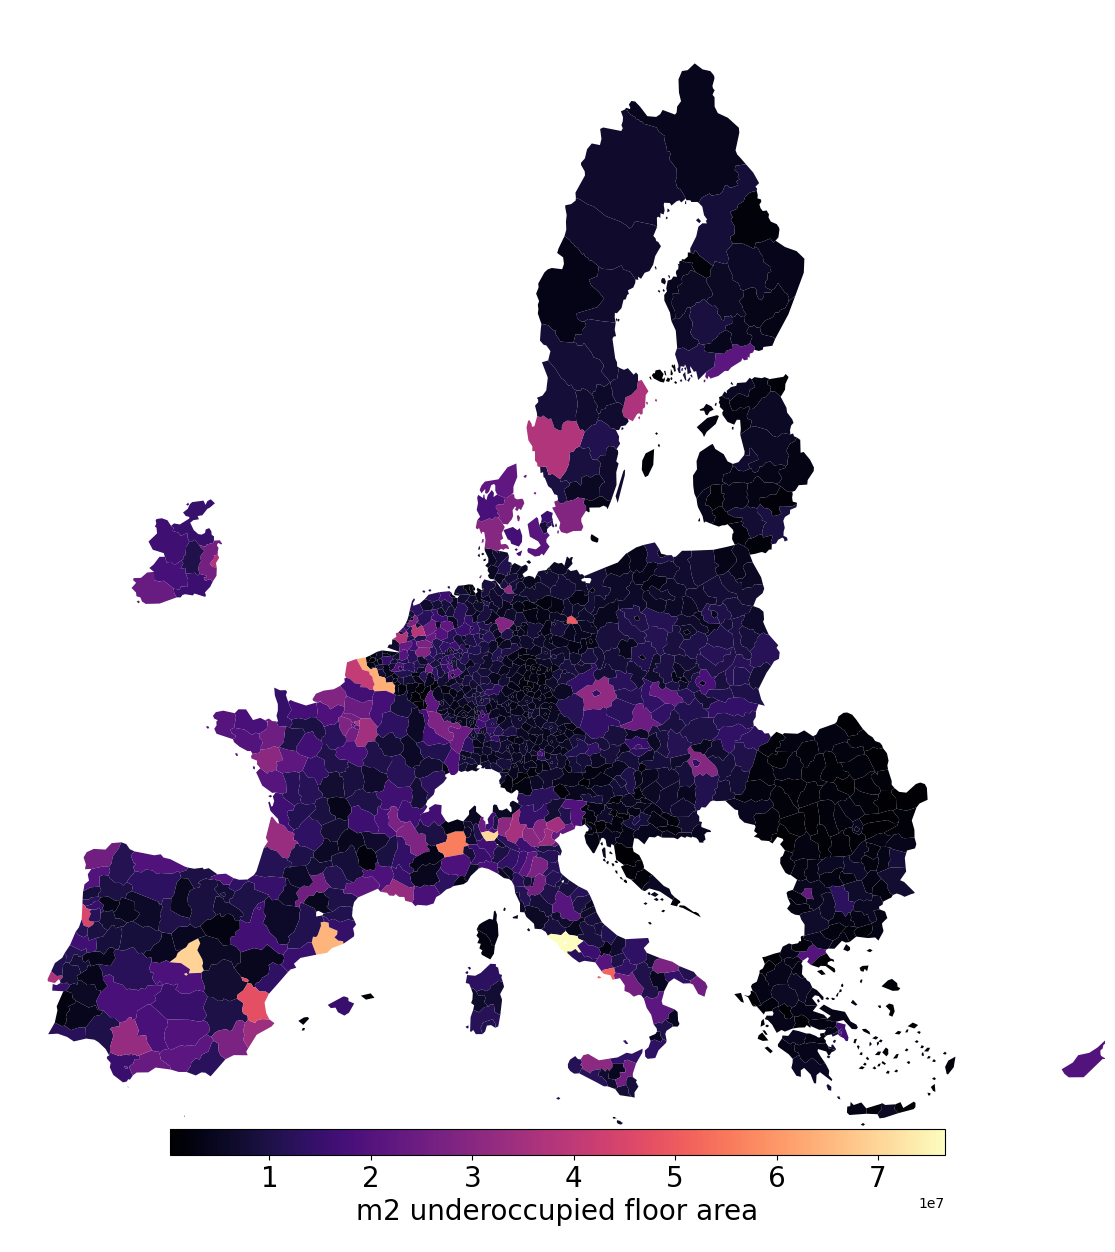

In [33]:
mat = pd.read_csv('/Users/Mira/Desktop/MCC/Code/EUBUCCO-IAM/underoccupancy_excess_demand_2025-2050.csv')
mat['NUTS_ID'] = mat.region_nuts.str[10:]
mat_gdf = pd.merge(mat, nuts, on='NUTS_ID')

gdf = gpd.GeoDataFrame(mat_gdf.replace(0, np.nan))
col = 'm2_excess' #m2 per cap
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              #cmap='RdBu_r', 
              cmap='magma', #inferno_r
              #norm=colors.LogNorm(vmin=0.01, vmax=gdf[col].max()),
              #norm=custom_norm, 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
              legend_kwds={"shrink":.5, 
                           "orientation":"horizontal",
                           "fraction":0.2,
                           "aspect":30,
                           "pad":0,
                           "anchor":(0.5, 1.4)},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.figure.axes[1].set_xlabel(xlabel='m2 underoccupied floor area', size=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()
#plt.savefig('plots/map_'+col+'_'+str(year)+'.png', bbox_inches='tight')

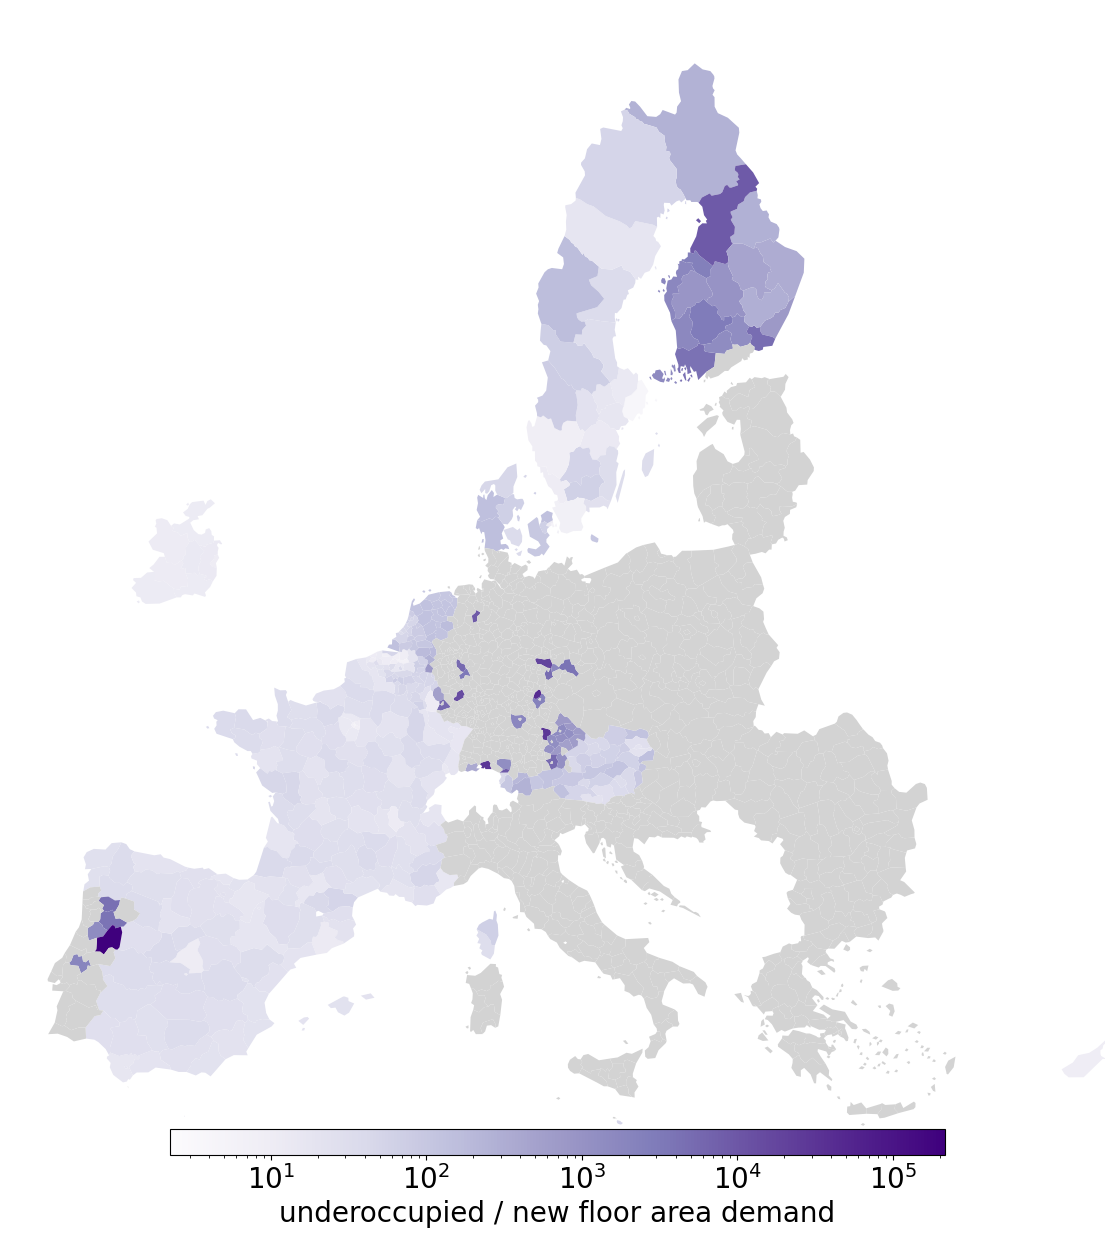

In [34]:
mat = pd.read_csv('/Users/Mira/Desktop/MCC/Code/EUBUCCO-IAM/underoccupancy_excess_demand_2025-2050.csv')
mat['NUTS_ID'] = mat.region_nuts.str[10:]
mat['excess_over_demand'] = (mat['m2_excess']/mat['m2_demand_new']).replace([np.inf, -np.inf, 0], np.nan)
mat_gdf = pd.merge(mat, nuts, on='NUTS_ID')

gdf = gpd.GeoDataFrame(mat_gdf.replace(0, np.nan))
col = 'excess_over_demand' #m2 per cap
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              #cmap='RdBu_r', 
              cmap='Purples', #inferno_r
              norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
              #norm=custom_norm, 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
              legend_kwds={"shrink":.5, 
                           "orientation":"horizontal",
                           "fraction":0.2,
                           "aspect":30,
                           "pad":0,
                           "anchor":(0.5, 1.4)},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.figure.axes[1].set_xlabel(xlabel='underoccupied / new floor area demand', size=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()
#plt.savefig('plots/map_'+col+'_'+str(year)+'.png', bbox_inches='tight')

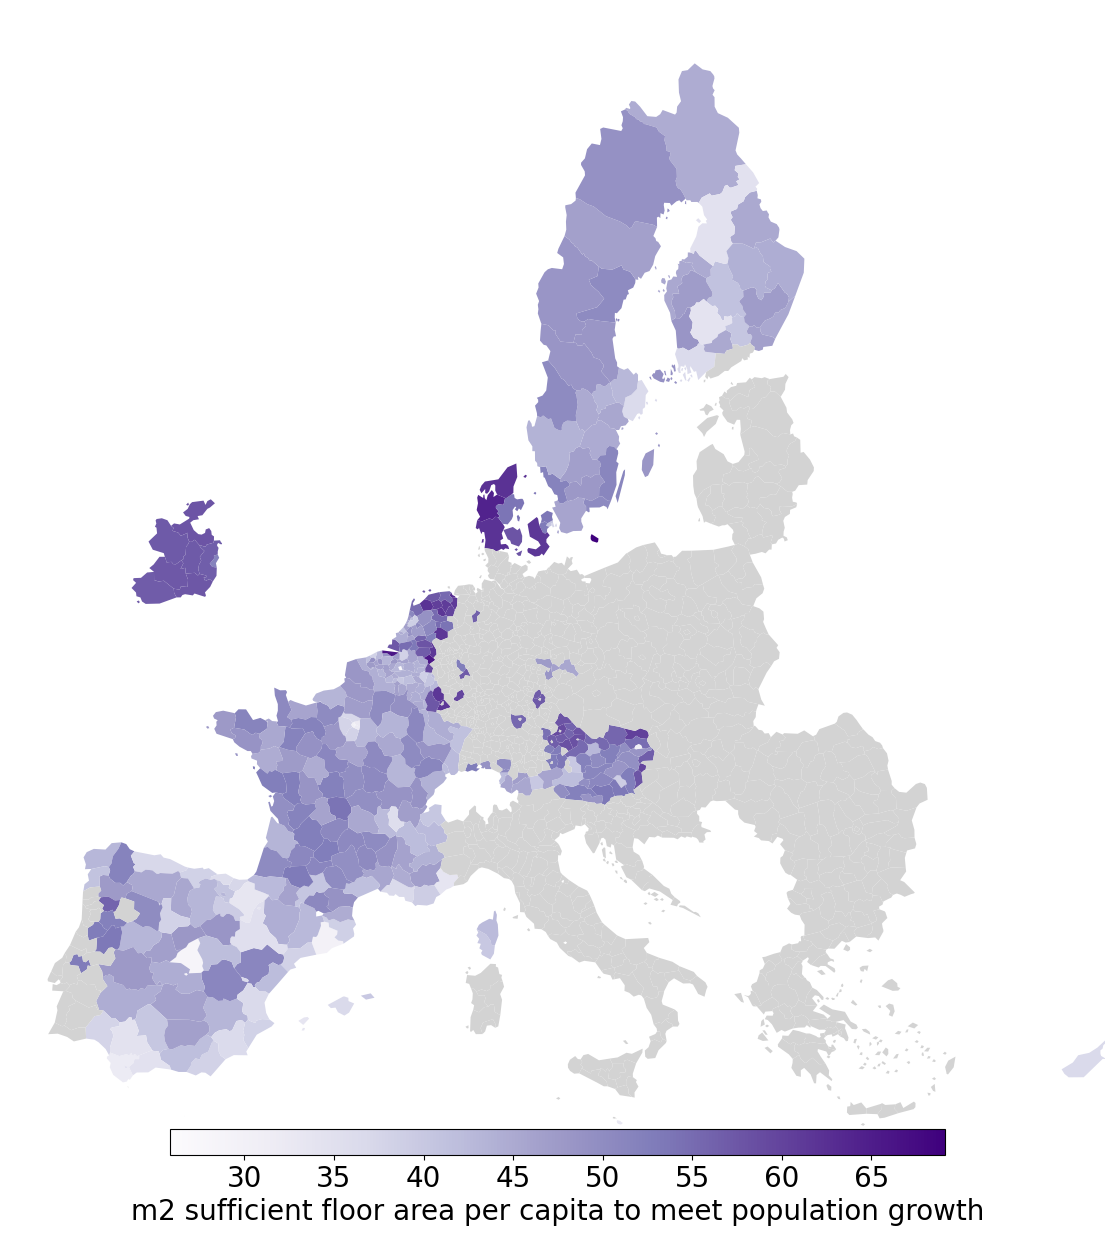

In [38]:
mat = pd.read_csv('/Users/Mira/Desktop/MCC/Code/EUBUCCO-IAM/underoccupancy_excess_demand_2025-2050.csv')
mat['NUTS_ID'] = mat.region_nuts.str[10:]
mat_gdf = pd.merge(mat, nuts, on='NUTS_ID')

gdf = gpd.GeoDataFrame(mat_gdf.replace(0, np.nan))
col = 'm2_per_cap_suff_match' #m2 per cap
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              #cmap='RdBu_r', 
              cmap='Purples', #inferno_r
              #norm=colors.LogNorm(vmin=0.01, vmax=gdf[col].max()),
              #norm=custom_norm, 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
                            legend_kwds={"shrink":.5, 
                           "orientation":"horizontal",
                           "fraction":0.2,
                           "aspect":30,
                           "pad":0,
                           "anchor":(0.5, 1.4)},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.figure.axes[1].set_xlabel(xlabel='m2 sufficient floor area per capita to meet population growth', size=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()
plt.savefig('plots/map_'+col+'.png', bbox_inches='tight')

In [ ]:
mat

,region_bld,region_nuts,urt,m2_per_cap,pop_trend,pop,m2_per_cap_suff,m2_excess,pop_new,m2_demand_new,scaling,m2_per_cap_suff_match,m2_per_cap_weighted,m2_per_cap_suff_match_weighted
0,C-EEU-BGR,C-EEU-BGR-BG311,rur,46.63,-0.42,0.05,37.58,"1,285,575.69",-0.02,0.00,0.00,0.00,2.15,0.00
1,C-EEU-BGR,C-EEU-BGR-BG311,sub,42.82,-0.21,0.03,36.90,"828,553.71",-0.01,0.00,0.00,0.00,1.46,0.00
2,C-EEU-BGR,C-EEU-BGR-BG311,urb,NaN,NaN,0.00,39.11,0.00,0.00,0.00,0.00,NaN,0.00,0.00
3,C-EEU-BGR,C-EEU-BGR-BG312,rur,43.38,-0.29,0.07,37.10,"1,701,214.23",-0.02,0.00,0.00,0.00,2.97,0.00
4,C-EEU-BGR,C-EEU-BGR-BG312,sub,39.83,-0.17,0.05,36.44,"1,055,601.11",-0.01,0.00,0.00,0.00,1.94,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3490,C-WEU-SWE,C-WEU-SWE-SE331,sub,46.48,0.07,0.06,39.73,"1,552,024.97",0.00,"76,669.85",4.63,45.16,2.70,2.63
3491,C-WEU-SWE,C-WEU-SWE-SE331,urb,39.03,0.12,0.07,39.73,"1,429,233.49",0.01,"180,967.84",3.75,36.60,2.90,2.72
3492,C-WEU-SWE,C-WEU-SWE-SE332,rur,48.98,0.03,0.13,40.86,"3,684,621.45",0.00,"66,641.67",4.80,48.46,6.27,6.20
3493,C-WEU-SWE,C-WEU-SWE-SE332,sub,47.66,0.03,0.11,40.86,"3,074,831.16",0.00,"67,785.51",4.66,47.05,5.34,5.27


In [2]:
# Material sheets
#data
scenarios = {"-NUTS":"region_nuts", "-NUTS-BLD":"region_bld", "-NUTS-BLD-FLAT":"region_bld"} #["-baseline", "-CCS-dwn", "-CCS-dwn-cutoff", "-DLS"]#["-NUTS-BLD", "-NUTS-BLD-DLS", "-NUTS-BLD-CCS-dwn", "-NUTS-BLD-CCS-dwn-uniform", "-NUTS-BLD-CCS-dwn-high", "-NUTS-BLD-CCS-shr", "-NUTS-BLD-CCS-shr-uniform", "-NUTS-BLD-CCS-mov", "-NUTS-BLD-CCS-mov-uniform",]

mat = pd.read_csv("output/report_STURM_SSP2"+list(scenarios.keys())[0]+"_resid_"+list(scenarios.values())[0]+"_material.csv")
if list(scenarios.values())[0]=='region_nuts':
    mat['region_bld'] = mat['region_nuts'].str[0:9]
mat = mat[mat['material']=='aluminum'].groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)[0:0]

for scenario, resolution in scenarios.items():
    df = pd.read_csv("output/report_STURM_SSP2"+scenario+"_resid_"+resolution+"_material.csv")
    if resolution=='region_nuts':
        df['region_bld'] = df['region_nuts'].str[0:9]
    df = df[df['material']=='aluminum'].groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)
    mat = pd.concat([mat, df])

In [3]:
data = mat.groupby(level=[1,2]).sum(numeric_only=True).floor_new_Mm2.reset_index()
data = data.replace({'SSP2-NUTS-BLD-FLAT':'3) National', 'SSP2-NUTS-BLD':'2) National x Climate x Urbanity', 'SSP2-NUTS':'1) NUTS3 Regions x Urbanity'})
data = data.sort_values(['scenario', 'year'], ascending=False)
fig = px.line(data, x="year", y="floor_new_Mm2", color="scenario", labels={"floor_new_Mm2":"EU Annual Construction Demand <br>[Million m<sup>2</sup> floor area]", 'scenario':'Resolution', 'year':'Year'}, template='simple_white', 
             color_discrete_sequence=px.colors.qualitative.Dark2)
fig.update_layout(width=700, height=500, legend={'traceorder': 'reversed'}, font=dict(size=16)) 
fig.update_yaxes(range=[0, 2.1e2]) 
fig.update_xaxes(range=[2025, 2050]) 
fig.write_image('plots/line_floor_new_Resolution.svg')
fig.write_image('plots/line_floor_new_Resolution.png')
fig.show()

In [4]:
df = data[data['year']<=2050].groupby('scenario').sum(numeric_only=True).drop('year', axis=1)
df = df.sort_values('scenario', ascending=False)
fig = px.bar(df, y="floor_new_Mm2", color=df.index, labels={"floor_new_Mm2":"EU Construction Demand 2025-2050 <br>[Million m<sup>2</sup> floor area]", 'scenario':'Resolution', 'year':'Year'}, template='simple_white', 
             color_discrete_sequence=px.colors.qualitative.Dark2)
fig.update_layout(width=700, height=600, legend={'traceorder': 'reversed'}, font=dict(size=16)) 
fig.update_xaxes(categoryorder='array', categoryarray= ['1) NUTS3 Regions x Urbanity', '2) National x Climate x Urbanity', '3) National'])
fig.write_image('plots/bar_floor_new_Resolution.svg')
fig.write_image('plots/bar_floor_new_Resolution.png')
fig.show()

In [26]:
data = mat.groupby(level=[1,2]).sum(numeric_only=True).mat_demand_Mt.reset_index()
data = data.replace({'SSP2-NUTS-BLD-FLAT':'3) National', 'SSP2-NUTS-BLD':'2) National x Climate x Urbanity', 'SSP2-NUTS':'1) NUTS3 Regions x Urbanity'})
data = data.sort_values(['scenario', 'year'], ascending=False)
fig = px.line(data, x="year", y="mat_demand_Mt", color="scenario", labels={"mat_demand_Mt":"EU Annual Construction Material Demand <br>[Million tonnes]", 'scenario':'Resolution', 'year':'Year'}, template='simple_white', 
             color_discrete_sequence=px.colors.qualitative.Dark2)
fig.update_layout(width=700, height=500, legend={'traceorder': 'reversed'}, font=dict(size=16)) 
fig.update_yaxes(range=[0, 0.3]) 
fig.update_xaxes(range=[2025, 2050]) 
#fig.write_image('plots/line_floor_tot_SSP2_Willing_DLS.svg')
#fig.write_image('plots/line_floor_tot_SSP2_Willing_DLS.png')
fig.show()

In [32]:
data[data['year']<=2050].groupby('scenario').sum(numeric_only=True).drop('year', axis=1)

,mat_demand_Mt
scenario,
1) NUTS3 Regions x Urbanity,1.46
2) National x Climate x Urbanity,1.45
3) National,1.33


In [44]:
df = data[data['year']<=2050].groupby('scenario').sum(numeric_only=True).drop('year', axis=1)
df = df.sort_values('scenario', ascending=False)
fig = px.bar(df, y="mat_demand_Mt", color=df.index, labels={"mat_demand_Mt":"EU Construction Material Demand 2025-2050 <br>[Million tonnes]", 'scenario':'Resolution', 'year':'Year'}, template='simple_white', 
             color_discrete_sequence=px.colors.qualitative.Dark2)
fig.update_layout(width=700, height=700, legend={'traceorder': 'reversed'}, font=dict(size=16)) 
fig.show()

In [3]:
mat.groupby(level=[1,2]).sum(numeric_only=True).floor_new_Mm2.unstack('year')[2050]

scenario
SSP2-NUTS            158.13
SSP2-NUTS-BLD        156.86
SSP2-NUTS-BLD-FLAT   151.22
Name: 2050, dtype: float64

In [12]:
mat.groupby(level=[1,2]).sum(numeric_only=True).floor_new_Mm2.unstack('year')[2050]

scenario
SSP2-NUTS-BLD                   156.86
SSP2-NUTS-BLD-CCS-dwn           136.62
SSP2-NUTS-BLD-CCS-dwn-uniform    62.05
SSP2-NUTS-BLD-DLS                68.80
Name: 2050, dtype: float64

In [13]:
1-136/156

0.1282051282051282

In [21]:
# Material sheets
#data
scenarios = {"-NUTS-BLD":'region_bld', 
                "-NUTS-BLD-CCS-dwn-high":'region_bld', 
                "-NUTS-BLD-CCS-dwn":'region_bld', 
                "-NUTS-BLD-DLS":'region_bld'}#["-NUTS-BLD", "-NUTS-BLD-DLS", "-NUTS-BLD-CCS-dwn", "-NUTS-BLD-CCS-dwn-uniform", "-NUTS-BLD-CCS-dwn-high", "-NUTS-BLD-CCS-shr", "-NUTS-BLD-CCS-shr-uniform", "-NUTS-BLD-CCS-mov", "-NUTS-BLD-CCS-mov-uniform",] #, "-NUTS-BLD-CCS-dwn-uniform":'region_bld', "-NUTS-BLD-CCS-shr":'region_bld', "-NUTS-BLD-CCS-shr-uniform":'region_bld', "-NUTS-BLD-CCS-mov":'region_bld', "-NUTS-BLD-CCS-mov-uniform":'region_bld',"-NUTS-BLD-DLS":'region_bld'}#["-NUTS-BLD", "-NUTS-BLD-DLS", "-NUTS-BLD-CCS-dwn", "-NUTS-BLD-CCS-dwn-uniform", "-NUTS-BLD-CCS-dwn-high", "-NUTS-BLD-CCS-shr", "-NUTS-BLD-CCS-shr-uniform", "-NUTS-BLD-CCS-mov", "-NUTS-BLD-CCS-mov-uniform",]


mat = pd.read_csv("output/report_STURM_SSP2"+list(scenarios.keys())[0]+"_resid_"+list(scenarios.values())[0]+"_material.csv")
if list(scenarios.values())[0]=='region_nuts':
    mat['region_bld'] = mat['region_nuts'].str[0:9]
mat = mat[mat['material']=='aluminum'].groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)[0:0]

for scenario, resolution in scenarios.items():
    df = pd.read_csv("output/report_STURM_SSP2"+scenario+"_resid_"+resolution+"_material.csv")
    if resolution=='region_nuts':
        df['region_bld'] = df['region_nuts'].str[0:9]
    df = df[df['material']=='aluminum'].groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)
    mat = pd.concat([mat, df])

In [35]:
data = mat.groupby(level=[1,2]).sum(numeric_only=True).floor_new_Mm2.reset_index()
data.replace('SSP2-NUTS-BLD-CCS-dwn-high','SSP2-NUTS-BLD-CCS-high', inplace=True)
data = data.sort_values(['scenario', 'year'], ascending=False)
data = data.replace({'SSP2-NUTS-BLD':'Baseline (SSP2)', 
                     'SSP2-NUTS-BLD-DLS':'Full adoption of <br>floor space sufficiency', 
                     'SSP2-NUTS-BLD-CCS-dwn':'Current willingness <br>(Circular Consumption Survey)', 
                     'SSP2-NUTS-BLD-CCS-high':'Higher willingness with raised awareness <br>(Circular Consumption Survey)'}) #, 'SSP2-NUTS-BLD-CCS-shr':'Current willingness to share <br>(Circular Consumption Survey)', 'SSP2-NUTS-BLD-CCS-shr-uniform':'Current willingness to share - not stratified <br>(Circular Consumption Survey)', 'SSP2-NUTS-BLD-CCS-mov':'Current willingness to move <br>(Circular Consumption Survey)', 'SSP2-NUTS-BLD-CCS-mov-uniform':'Current willingness to move - not stratified <br>(Circular Consumption Survey)'})
fig = px.line(data, x="year", y="floor_new_Mm2", color="scenario", labels={"floor_new_Mm2":"EU Annual Construction Demand <br>[Million m<sup>2</sup> floor area]", 'variable':'Land use type', 'index':'year'}, template='simple_white', 
             color_discrete_sequence=px.colors.qualitative.Dark2_r)
fig.update_layout(width=800, height=500, legend={'traceorder': 'reversed'}, font=dict(size=16)) 
fig.update_yaxes(range=[0, 205]) 
fig.update_xaxes(range=[2025, 2050]) 
fig.write_image('plots/line_floor_new_SSP2-NUTS-BLD_Willing_stratified_DLS.svg')
fig.write_image('plots/line_floor_new_SSP2-NUTS-BLD_Willing_stratified_DLS.png')
fig.show()

In [13]:
70/157

0.445859872611465

In [12]:
data[data.year==2050]

,scenario,year,floor_new_Mm2
19,SSP2-NUTS-BLD-CCS-dwn-uniform,2050,62.05
49,Full adoption of <br>floor space sufficiency,2050,69.60
37,Current willingness to share <br>(Circular Con...,2050,143.18
43,Current willingness to share - not stratified ...,2050,109.48
25,Current willingness to move <br>(Circular Cons...,2050,135.85
31,Current willingness to move - not stratified <...,2050,78.45
13,Current willingness <br>(Circular Consumption ...,2050,136.62
5,Baseline (SSP2),2050,156.86


In [16]:
1-1012.758790232886/1362.47018603088

0.25667453085103176

In [39]:
(1082-1012)/(1082-790)

0.23972602739726026

In [40]:
(1082-940)/(1082-790)

0.4863013698630137

In [38]:
1-790.9955358456817/1082.39500396722

0.2692173070399383

In [37]:
data[data.year<=2050].groupby('scenario').sum()

,year,floor_new_Mm2
scenario,,
Baseline (SSP2),12225,"1,082.40"
Current willingness <br>(Circular Consumption Survey),12225,"1,012.76"
Full adoption of <br>floor space sufficiency,12225,791.00
Higher willingness with raised awareness <br>(Circular Consumption Survey),12225,940.88


In [21]:
data = mat.drop('SSP2-NUTS-BLD-CCS-dwn-uniform', axis=0, level=1).groupby(level=[1,2]).sum(numeric_only=True).floor_new_Mm2.reset_index()
data = data.replace({'SSP2-NUTS-BLD':'Baseline (SSP2)', 'SSP2-NUTS-BLD-DLS':'Full adoption of <br>floor space sufficiency', 'SSP2-NUTS-BLD-CCS-dwn':'Current willingness <br>(Circular Consumption Survey)'})
data = data.sort_values(['scenario', 'year'], ascending=False)
fig = px.line(data, x="year", y="floor_new_Mm2", color="scenario", labels={"floor_new_Mm2":"EU Annual Construction Demand <br>[Million m<sup>2</sup> floor area]", 'variable':'Land use type', 'index':'year'}, template='simple_white', 
             color_discrete_sequence=px.colors.qualitative.Dark24)
fig.update_layout(width=700, height=500, legend={'traceorder': 'reversed'}, font=dict(size=16)) 
fig.update_yaxes(range=[0, 205]) 
fig.update_xaxes(range=[2025, 2050]) 
fig.write_image('plots/line_floor_new_SSP2-NUTS-BLD_Willing_DLS.svg')
fig.write_image('plots/line_floor_new_SSP2-NUTS-BLD_Willing_DLS.png')
fig.show()

In [17]:
data = mat.drop('SSP2-CCS-dwn-cutoff', level=1).groupby(level=[1,2]).sum(numeric_only=True).floor_tot_Mm2.reset_index()
data = data.replace({'SSP2-baseline':'Baseline (SSP2)', 'SSP2-DLS':'Full adoption of <br>floor space sufficiency', 'SSP2-CCS-dwn':'Current willingness <br>(Circular Consumption Survey)'})
data = data.sort_values(['scenario', 'year'], ascending=False)
fig = px.line(data, x="year", y="floor_tot_Mm2", color="scenario", labels={"floor_tot_Mm2":"EU Annual Construction Demand <br>[Million m<sup>2</sup> floor area]", 'variable':'Land use type', 'index':'year'}, template='simple_white', 
             color_discrete_sequence=px.colors.qualitative.Dark2)
fig.update_layout(width=700, height=500, legend={'traceorder': 'reversed'}, font=dict(size=16)) 
fig.update_yaxes(range=[0, 20e3]) 
fig.write_image('plots/line_floor_tot_SSP2_Willing_DLS.svg')
fig.write_image('plots/line_floor_tot_SSP2_Willing_DLS.png')
fig.show()

In [25]:
data = mat.groupby(level=[1,2]).sum(numeric_only=True).floor_tot_Mm2.reset_index()
data = data.replace({'SSP2-baseline':'Baseline (SSP2)', 'SSP2-DLS':'Technical potential (Decent Living Standards)', 'SSP2-CCS-dwn':'Current willingness (Circular Consumption Survey)'})
data = data.sort_values(['scenario', 'year'], ascending=False)
fig = px.line(data, x="year", y="floor_tot_Mm2", color="scenario", labels={"floor_tot_Mm2":"Total Annual Construction Demand in the EU <br>[Million m<sup>2</sup> floor area]", 'variable':'Land use type', 'index':'year'}, template='simple_white', 
             color_discrete_sequence=px.colors.qualitative.Dark2)
fig.update_layout(width=900, height=500, legend={'traceorder': 'reversed'}) 
fig.write_image('plots/line_floor_tot_SSP2_Willing_DLS.svg')
fig.write_image('plots/line_floor_tot_SSP2_Willing_DLS.png')
fig.show()

(0.0, 161.10975472381028)

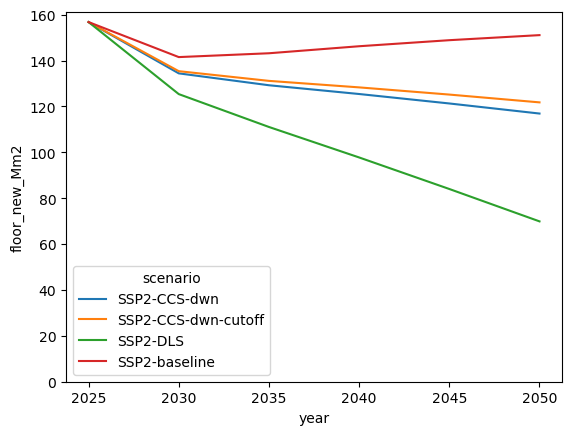

In [ ]:
#- total difference in added floor area #floor_new_Mm2 --> how much does this reduce expansion?
# result: all scenarios reduce newly constructed floor area in the first time step, CCS also reduce floor area beyond, moving more than sharing
# strange: baseline also reduces newly constructed floor area in the first time step
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True).floor_new_Mm2.reset_index(), x="year", y="floor_new_Mm2", hue="scenario")
ax.set_ylim(bottom=0)

(0.0, 12.54363593881481)

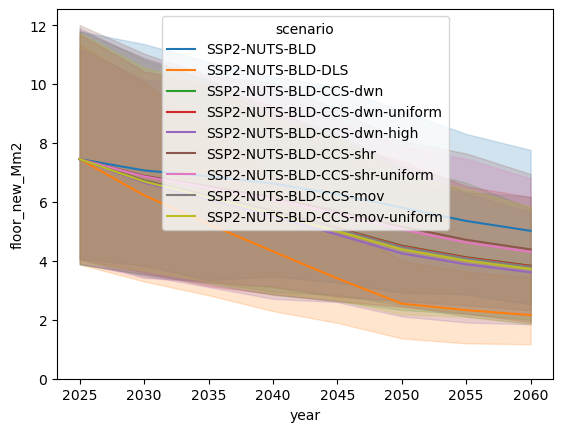

In [16]:
#- total difference in added floor area #floor_new_Mm2 --> how much does this reduce expansion?
# result: all scenarios reduce newly constructed floor area, CCS also reduce floor area more with CCS
# strange: baseline also reduces newly constructed floor area in the first time step
ax = sns.lineplot(data=mat.floor_new_Mm2.reset_index(), x="year", y="floor_new_Mm2", hue="scenario")# hue="region_bld",style="scenario")
ax.set_ylim(bottom=0)

In [15]:
mat

floor_tot_Mm2  \
region_bld scenario                              year                  
C-EEU-BGR  SSP2-NUTS-BLD                         2025       1,798.40   
                                                 2030       1,845.76   
                                                 2035       1,885.07   
                                                 2040       1,918.00   
                                                 2045       1,945.19   
...                                                              ...   
C-WEU-SWE  SSP2-NUTS-BLD-CCS-shr-uniform-hhfixed 2040       3,170.93   
                                                 2045       3,200.05   
                                                 2050       3,224.24   
                                                 2055       3,287.11   
                                                 2060       3,340.86   

                                                       floor_new_Mm2  \
region_bld scenario                              year                  
C-EEU-BGR  SSP2-NUTS-BLD                         2025          14.55   
                                                 2030          13.69   
                                                 2035          12.41   
                                                 2040          11.35   
                                                 2045          10.43   
...                                                              ...   
C-WEU-SWE  SSP2-NUTS-BLD-CCS-shr-uniform-hhfixed 2040          41.74   
                                                 2045          40.27   
                                                 2050          38.43   
                                                 2055          36.36   
                                                 2060          34.24   

                                                       floor_dem_Mm2  \
region_bld scenario                              year                  
C-EEU-BGR  SSP2-NUTS-BLD                         2025          24.54   
                                                 2030          24.07   
                                                 2035          23.11   
                                                 2040          21.82   
                                                 2045          20.41   
...                                                              ...   
C-WEU-SWE  SSP2-NUTS-BLD-CCS-shr-uniform-hhfixed 2040          26.90   
                                                 2045          25.73   
                                                 2050          24.61   
                                                 2055          24.03   
                                                 2060          23.68   

                                                       mat_stock_Mt  \
region_bld scenario                              year                 
C-EEU-BGR  SSP2-NUTS-BLD                         2025        391.36   
                                                 2030        400.52   
                                                 2035        407.98   
                                                 2040        414.09   
                                                 2045        419.00   
...                                                             ...   
C-WEU-SWE  SSP2-NUTS-BLD-CCS-shr-uniform-hhfixed 2040        547.50   
                                                 2045        552.36   
                                                 2050        556.42   
                                                 2055        567.02   
                                                 2060        576.08   

                                                       mat_demand_Mt  \
region_bld scenario                              year                  
C-EEU-BGR  SSP2-NUTS-BLD                         2025           2.77   
                                                 2030           2.67   
                                

(0.0, 208.369357934831)

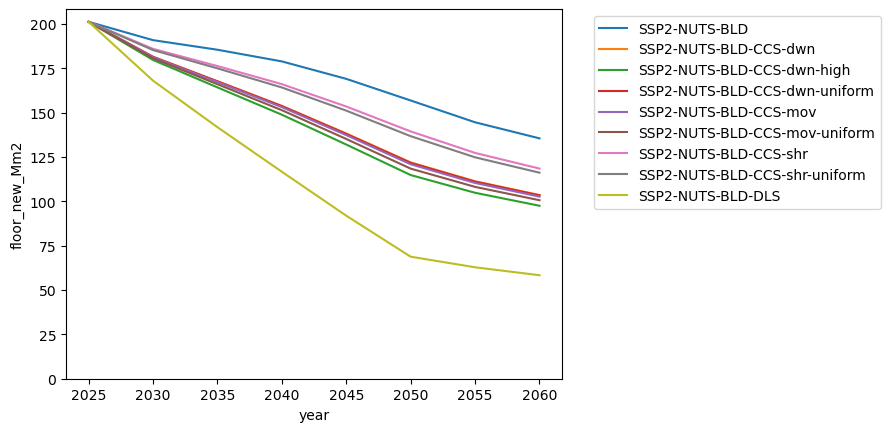

In [17]:
#- total difference in added floor area #floor_new_Mm2 --> how much does this reduce expansion?
# result: all scenarios reduce newly constructed floor area, CCS also reduce floor area more with CCS
# strange: baseline also reduces newly constructed floor area in the first time step
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True).floor_new_Mm2.reset_index(), x="year", y="floor_new_Mm2", hue="scenario")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(bottom=0)

In [21]:
mat.groupby(level=[1,2]).sum(numeric_only=True).drop('SSP2-NUTS-BLD-CCS-shr-hhfixed', axis=0, level=0)

floor_tot_Mm2  floor_new_Mm2  \
scenario                              year                                 
SSP2-NUTS-BLD                         2025     126,615.21       1,408.58   
                                      2030     128,832.29       1,336.16   
                                      2035     130,729.28       1,298.30   
                                      2040     132,316.17       1,252.28   
                                      2045     133,504.23       1,183.40   
                                      2050     134,224.02       1,098.04   
                                      2055     134,486.82       1,011.96   
                                      2060     134,426.59         948.57   
SSP2-NUTS-BLD-CCS-dwn                 2025     126,615.21       1,408.58   
                                      2030     122,048.20       1,268.91   
                                      2035     117,327.08       1,170.68   
                                      2040     112,496.08       1,071.87   
                                      2045     107,511.03         961.39   
                                      2050     102,349.59         846.38   
                                      2055     101,426.37         772.55   
                                      2060     100,394.24         718.53   
SSP2-NUTS-BLD-CCS-dwn-uniform         2025     126,615.21       1,408.58   
                                      2030     121,652.61       1,264.64   
                                      2035     116,533.14       1,162.32   
                                      2040     111,302.76       1,059.75   
                                      2045     105,920.30         946.18   
                                      2050     100,368.24         829.08   
                                      2055      99,458.92         757.11   
                                      2060      98,444.54         704.43   
SSP2-NUTS-BLD-CCS-shr                 2025     126,615.21       1,408.58   
                                      2030     125,338.33       1,022.35   
                                      2035     123,883.90         966.91   
                                      2040     122,286.58         908.20   
                                      2045     120,484.21         833.14   
                                      2050     118,431.24         746.05   
                                      2055     117,342.84         942.53   
                                      2060     116,132.97         868.59   
SSP2-NUTS-BLD-CCS-shr-uniform         2025     126,615.21       1,408.58   
                                      2030     124,866.08         945.96   
                                      2035     122,942.53         892.65   
                                      2040     120,880.61         836.14   
                                      2045     118,620.43         763.34   
                                      2050     116,119.44         679.07   
                                      2055     115,052.80         936.44   
                                      2060     113,866.03         861.05   
SSP2-NUTS-BLD-CCS-shr-uniform-hhfixed 2025     126,615.21       1,408.58   
                                      2030     124,866.08       1,297.08   
                                      2035     122,942.54       1,224.85   
                                      2040     120,880.61       1,149.45   
                                      2045     118,620.45       1,058.00   
                                      2050     116,119.46         957.17   
                                      2055     115,052.83         873.78   
                                      2060     113,866.05         813.03   
SSP2-NUTS-BLD-DLS                     2025     126,615.21       1,408.58   
                                      2030     113,069.08       1,176.37   
                                      2035      99,397.57         992.65   
                

(0.0, 19765.629989965986)

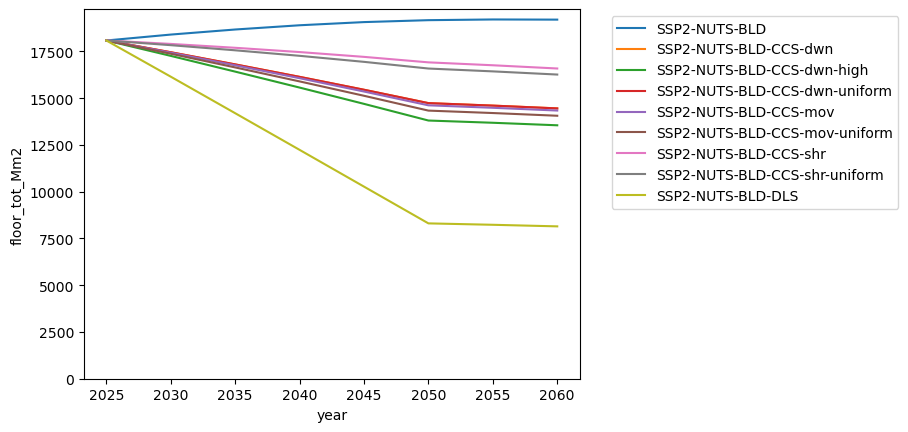

In [18]:
#- total difference in total floor area #floor_tot_Mm2 --> how much does this reduce demand for construction including reconstruction? i.e. can this reduced demand for housing not only halt expansion but also reduce the need to replace buildings at end of life?
# result: while baseline increases total constructed floor area continuously, CCS reduces floor area, moving more than sharing
# strange: edge pattern from new construction does not show up in total construction not even slightly
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True).floor_tot_Mm2.reset_index(), x="year", y="floor_tot_Mm2", hue="scenario")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(bottom=0)

(0.0, 186.080862089868)

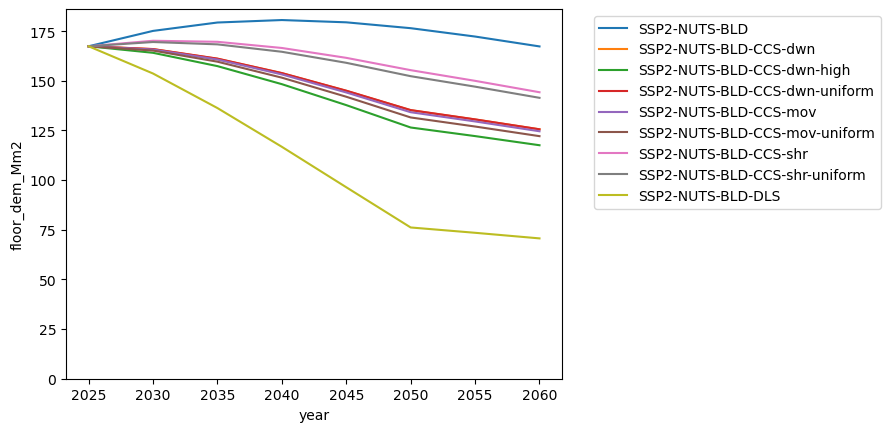

In [19]:
# result: demolition is lower in those scenarios that have particularly strong reduction in floor area per capita
# QQ: what is demolition driven by in the model? by demolition rate and existing stock?
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True).floor_dem_Mm2.reset_index(), x="year", y="floor_dem_Mm2", hue="scenario")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(bottom=0)

In [25]:
#data
ene = pd.read_csv("output/report_STURM_SSP2-NUTS-BLD_resid_region_bld_energy.csv")
ene_bld = ene.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

ene = pd.read_csv("output/report_STURM_SSP2-NUTS-BLD-DLS_resid_region_bld_energy.csv")
ene_dls = ene.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

ene = pd.read_csv("output/report_STURM_SSP2-NUTS-BLD-CCS-dwn_resid_region_bld_energy.csv")
ene_dwn = ene.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

ene = pd.read_csv("output/report_STURM_SSP2-NUTS-BLD-CCS-shr_resid_region_bld_energy.csv")
ene_shr = ene.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

ene = pd.read_csv("output/report_STURM_SSP2-NUTS-BLD-CCS-dwn-uniform_resid_region_bld_energy.csv")
ene_dwn_uni = ene.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

ene = pd.read_csv("output/report_STURM_SSP2-NUTS-BLD-CCS-shr-uniform_resid_region_bld_energy.csv")
ene_shr_uni = ene.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

ene = pd.read_csv("output/report_STURM_SSP2-NUTS-BLD-CCS-shr-hhfixed_resid_region_bld_energy.csv")
ene_shr_hh = ene.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

ene = pd.read_csv("output/report_STURM_SSP2-NUTS-BLD-CCS-shr-uniform-hhfixed_resid_region_bld_energy.csv")
ene_shr_uni_hh = ene.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

ene = pd.concat([ene_bld, ene_dls, ene_dwn, ene_dwn_uni, ene_shr, ene_shr_uni, ene_shr_hh, ene_shr_uni_hh], axis=0)

(0.0, 19765.629989965983)

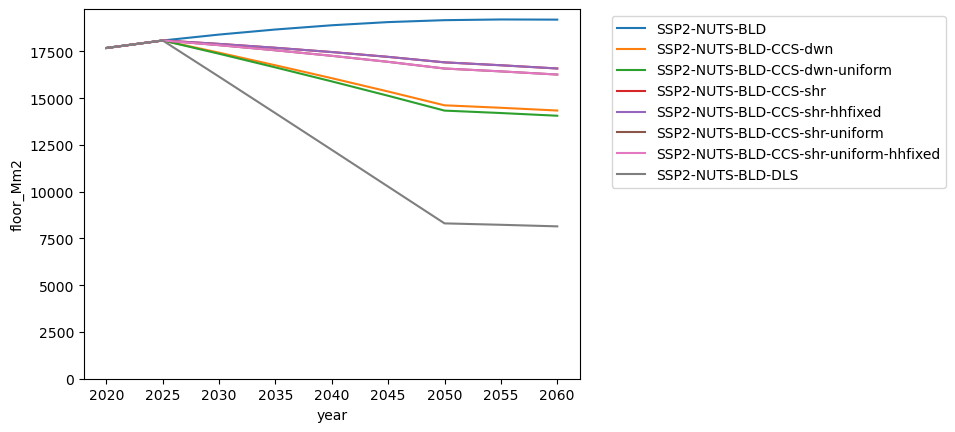

In [27]:
#- total difference in housing stocks? #floor_Mm2 --> does the reduced need for housing correspond to the reduced total floor area?
# result: yes, corresponds to trend in total floor area construction
# makes sense: measures only show after 2025 as introduced
ax = sns.lineplot(data=ene.groupby(level=[1,2]).sum(numeric_only=True).floor_Mm2.reset_index(), x="year", y="floor_Mm2", hue="scenario")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(bottom=0)

In [33]:
ene.groupby(level=[1,2]).sum(numeric_only=True).floor_Mm2.unstack(1)[2050]

scenario
SSP2-NUTS-BLD                           19,174.86
SSP2-NUTS-BLD-CCS-dwn                   14,621.37
SSP2-NUTS-BLD-CCS-dwn-uniform           14,338.32
SSP2-NUTS-BLD-CCS-shr                   16,918.75
SSP2-NUTS-BLD-CCS-shr-hhfixed           16,918.75
SSP2-NUTS-BLD-CCS-shr-uniform           16,588.49
SSP2-NUTS-BLD-CCS-shr-uniform-hhfixed   16,588.49
SSP2-NUTS-BLD-DLS                        8,307.39
Name: 2050, dtype: float64

In [18]:
ene.groupby(level=[1,2]).sum(numeric_only=True).stock_M.unstack('year')

year,2020,2025,2030,2035,2040,2045,2050,2055,2060
scenario,,,,,,,,,
SSP2-NUTS-BLD,198.45,199.26,199.29,199.01,198.48,197.62,196.34,NaN,NaN
SSP2-NUTS-BLD-CCS-dwn,198.45,199.26,199.29,199.01,198.48,197.62,196.34,194.67,192.80
SSP2-NUTS-BLD-CCS-dwn-uniform,198.45,199.26,199.29,199.01,198.48,197.62,196.34,194.67,192.80
SSP2-NUTS-BLD-CCS-shr,198.45,199.26,196.25,193.02,189.63,186.01,182.11,180.58,178.87
SSP2-NUTS-BLD-CCS-shr-hhfixed,198.45,199.26,199.29,199.01,198.48,197.62,196.34,194.67,192.80
SSP2-NUTS-BLD-CCS-shr-uniform,198.45,199.26,196.25,193.02,189.64,186.03,182.14,180.63,178.92


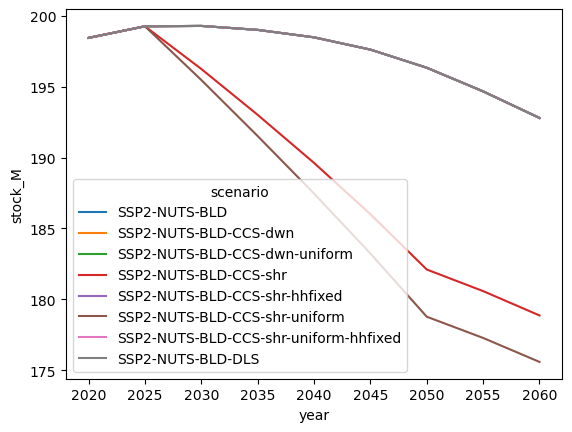

In [29]:
#- total difference in housing stocks? #floor_Mm2 --> does the reduced need for housing correspond to the reduced total floor area?
# result: exactly same amount of dwellings in baseline and downsizing scenario, but higher stock of dwellings in sharing scenario with larger household sizes
# strange: higher stock of dwellings not expected (if then lower stock), also does not make sense that already before onset of measures in 2020
ax = sns.lineplot(data=ene.groupby(level=[1,2]).sum(numeric_only=True).stock_M.reset_index(), x="year", y="stock_M", hue="scenario")
#ax.set_ylim(bottom=0)